In [88]:
# * Imports

import numpy as np
import matplotlib.pyplot as plt  # * For Plotting
import scipy as sp
from scipy import integrate  # * For Solving Differential Equations
import snoop  # * For Debugging Purpose

from scipy.optimize import brentq
from numbalsoda import lsoda_sig, lsoda, solve_ivp  # Faster Method
from NumbaMinpack import lmdif, hybrd, minpack_sig
import numba as nb  # For Speeding Up
import scipy.integrate as integrate
from scipy.interpolate import CubicSpline
from scipy.spatial import KDTree
from scipy.sparse import coo_array

In [89]:
# Parameters

mu = 1.0  #! This Value was not given in paper. I solved it
#! using the constraint on the total energy
M = 1.0
L = 1.0
z0 = 0.5
alpha = 0.01  # TODO Important Parameter.
ics = np.array(
    [1.2, 0.0, 0.0, 0.0, 0.76, L]
)  # * Initial conditions w,z,phi, pw,pz,pphi from paper
t = np.arange(0.0, 100000.0, 1)  # Time Steps for evolution

tau = 100  # Renormalization time
tf = 1000000.0  # Final time
steps = 10000  # *Number of time steps between each time interval
# Theory Parameters

Theta = np.pi / 2
Psi = 0.0
R = 1e10

Fp = 0.2
Fc = 0.3

tm = np.linspace(0.0, 500000.0, 5000000)  # Time for integrations
tm2 = np.linspace(0.0, 10000.0, 100000)

In [90]:
@nb.njit
def logcosh(x):
    # s always has real part >= 0
    s = np.sign(x) * x
    p = np.exp(-2 * s)
    return s + np.log1p(p) - np.log(2)

In [91]:
@nb.njit
# @snoop
def H(mu: np.float64, ics: np.ndarray, alpha: np.int32) -> np.ndarray:
    """

    Args:
        mu (float): Mass of the Test Particle
        ics (np.ndarray): The Phase Space Coordinates of the particle
                        Shape(n,4)

    Returns:
        Energy of the particel (np.ndarray): Shape (n,)
    """
    if ics.ndim == 1:
        w, z, phi, pw, pz, pphi = ics[0], ics[1], ics[2], ics[3], ics[4], ics[5]
    else:
        w, z, phi, pw, pz, pphi = (
            ics[:, 0],
            ics[:, 1],
            ics[:, 2],
            ics[:, 3],
            ics[:, 4],
            ics[:, 5],
        )
    L = pphi

    return mu * (
        pw**2 / (2 * mu)
        + pz**2 / (2 * mu)
        + L**2 / (2 * mu**2 * w**2)
        - M / np.sqrt(w**2 + z**2)
        + alpha * z0 * logcosh(z / z0)
    )

In [92]:
@nb.njit
def evolve(t: float, x: np.ndarray, alpha: int) -> np.ndarray:
    """
    Function for solving Differential Equation
    Args:
        t (float): Time Step
        x (np.ndarray): Shape (n,)

    Returns:
        Output (np.ndarray): Shape (n,)
    """
    w, z, phi, pw, pz, pphi = x
    dw = pw
    dz = pz
    dphi = L / (mu * w**2)

    dpw = -mu * (-(L**2) / (mu**2 * w**3) + M * w / ((w**2 + z**2) ** (3 / 2)))
    dpz = -mu * (M * z / ((w**2 + z**2) ** (3 / 2)) + alpha * np.tanh(z / z0))
    dpphi = 0.0

    return np.array((dw, dz, dphi, dpw, dpz, dpphi))

In [93]:
@nb.njit
def poincare(t: float, y: np.ndarray, args: np.int32) -> float:
    """Creating Poincare Section

    Args:
        t (float): time Step
        y (np.ndarray): Shape (n,4)
        args (np.int32) : Not needed. But used for compatibility for
                            below methods

    Returns:
        float: The value where the function gets zero (z value in this case)
    """
    return y[1]

In [94]:
evolve(0.,ics,alpha);
poincare(0.,ics,alpha);

In [95]:
sol = integrate.solve_ivp(
    evolve,
    (0.0, t[-1]),
    ics,
    "LSODA",
    t_eval=t,
    events=poincare,
    dense_output=True,
    args=(alpha,),
    atol=1e-11,
    rtol=1e-11,
)

In [96]:
mask = sol.y_events[0][:, 4] > 0  # * Get those values where v_z is greater than zero

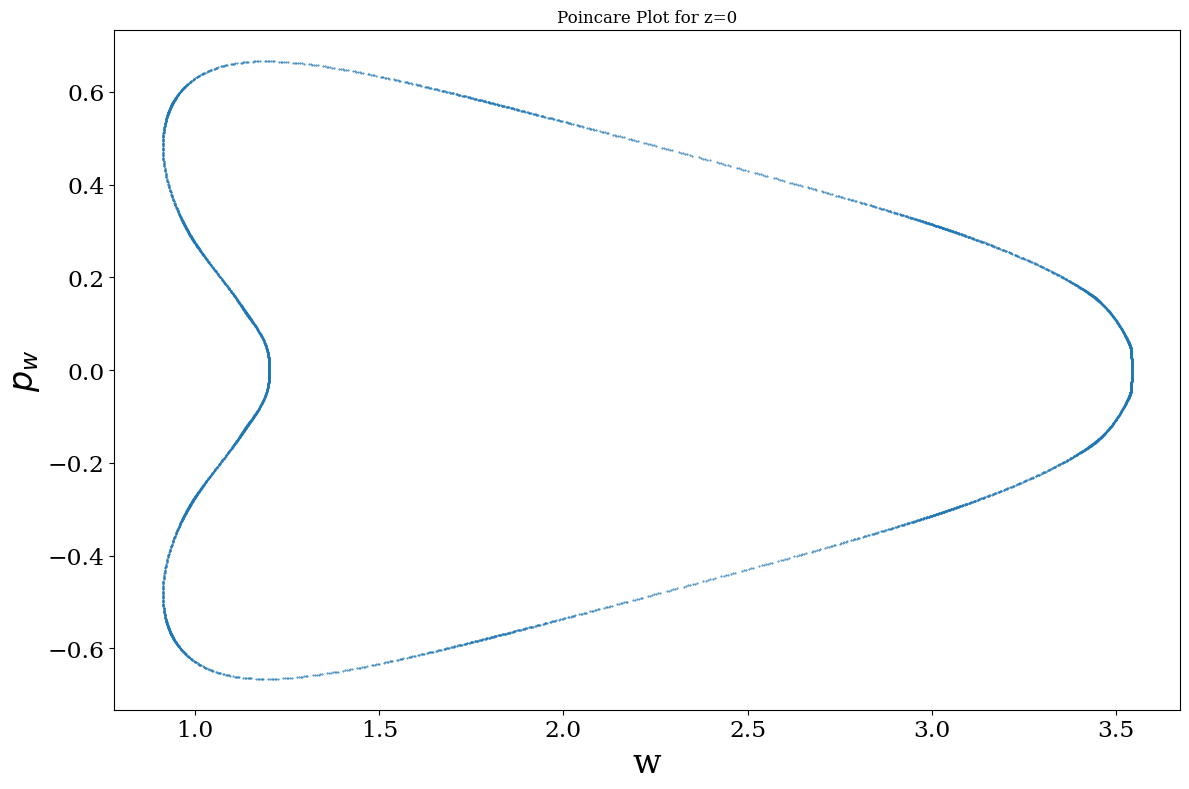

In [97]:
# * Poincare Plot

plt.scatter(sol.y_events[0][mask, 0], sol.y_events[0][mask, 3], s=0.2)
plt.title(r"Poincare Plot for z=0")
plt.xlabel(r"w")
plt.ylabel(r"$p_w$")
plt.tight_layout()
plt.savefig("poincare.png",dpi=300)

In [98]:
energy = H(mu, sol.y.T, alpha=alpha)  # Get the energy of given solutions

Text(0, 0.5, 'Energy')

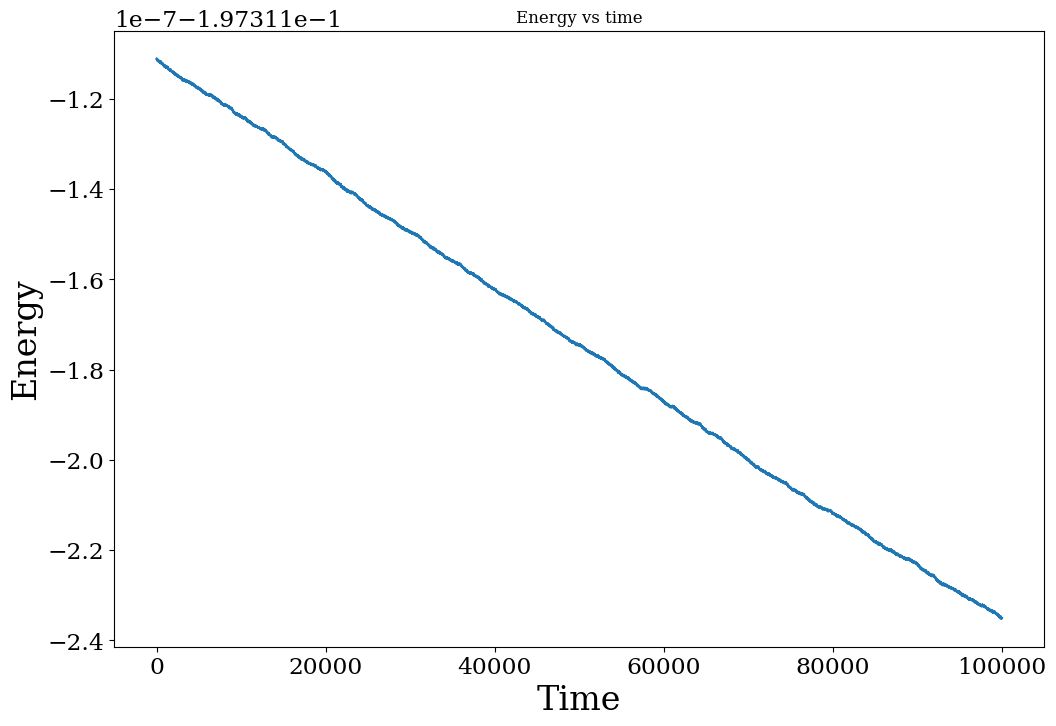

In [99]:
plt.plot(energy)
plt.title("Energy vs time")
plt.xlabel("Time")
plt.ylabel("Energy")

In [100]:
def chaotic_lyp(t, Y, alpha=alpha):
    """
    Function for solving the system of equation simultaneously with
    the Jacobian

    """

    # First system of equations

    w, z, phi, pw, pz, pphi = Y[:6]
    dw = pw
    dz = pz
    dphi = L / (mu * w**2)

    dpw = -mu * (-(L**2) / ((mu**2) * w**3) + M * w / ((w**2 + z**2) ** (3 / 2)))
    dpz = -mu * (M * z / ((w**2 + z**2) ** (3 / 2)) + alpha * np.tanh(z / z0))
    dpphi = 0.0

    dhdwdw = -mu * (
        3 * L**2 / ((mu**2) * (w**4))
        - 3 * M * w**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
    )
    dhdwdz = 3 * M * mu * w * z / ((w**2 + z**2) ** (5 / 2))
    dhdzdz = -mu * (
        -3 * M * z**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
        + alpha * (1 / (np.cosh(z / z0)) ** 2) / z0
    )

    # Now calculate the jacobian
    J = np.array(
        [
            [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
            [-2 * L / (mu * w**3), 0.0, 0.0, 0.0, 0.0, 1 / (mu * w**2)],
            [dhdwdw, dhdwdz, 0.0, 0.0, 0.0, 2 * L / (mu * w**3)],
            [dhdwdz, dhdzdz, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        ]
    )

    dY = Y[6:].reshape((6, 1))
    dY_dt = np.dot(J, dY)

    return np.concatenate(([dw, dz, dphi, dpw, dpz, dpphi], dY_dt.flatten()))

In [101]:
#! Faster implementaton of above function
@nb.cfunc(lsoda_sig)
def faster_chaotic_system(t, u, du, p):
    """
    The same system as above but faster than above method. This uses Numba
    and Numbalsoda for faster evaluations
    """
    u_ = nb.carray(u, (12,))
    p_ = nb.carray(p, (1,))
    alpha = p_[0]
    w, z, phi, pw, pz, pphi = u_[:6]
    dw = pw
    dz = pz
    dphi = L / (mu * w**2)

    dpw = -mu * (-(L**2) / ((mu**2) * w**3) + M * w / ((w**2 + z**2) ** (3 / 2)))
    dpz = -mu * (M * z / ((w**2 + z**2) ** (3 / 2)) + alpha * np.tanh(z / z0))
    dpphi = 0.0

    dhdwdw = -mu * (
        3 * L**2 / ((mu**2) * w**4)
        - 3 * M * w**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
    )
    dhdwdz = 3 * M * mu * w * z / ((w**2 + z**2) ** (5 / 2))
    dhdzdz = -mu * (
        -3 * M * z**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
        + alpha * (1 / (np.cosh(z / z0)) ** 2) / z0
    )

    # Now calculate the jacobian

    J = np.array(
        [
            [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
            [-2 * L / (mu * w**3), 0.0, 0.0, 0.0, 0.0, 1 / (mu * w**2)],
            [dhdwdw, dhdwdz, 0.0, 0.0, 0.0, 2 * L / (mu * w**3)],
            [dhdwdz, dhdzdz, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        ]
    )

    dY = u_[6:].reshape((6, 1))
    dY_dt = np.dot(J, dY)
    dydtf = dY_dt.flatten()
    du_ = np.zeros((12,), dtype=nb.float64)
    du_[:6] = np.array([dw, dz, dphi, dpw, dpz, dpphi])
    du_[6:] = dydtf

    for i in range(len(du_)):
        du[i] = du_[i]

pfunctptr = faster_chaotic_system.address

In [102]:
u0 = np.copy(ics)  # Initial condition for x(0)
w0 = np.random.normal(0.0, 1.0, (6))
w0 = w0 / np.linalg.norm(w0)  # Initial unitary deviation vector w(0)

ics0 = np.array((u0, w0)).flatten()  # Combined Initial vector

In [103]:
@nb.njit
def evolve_lyap(ics0, tau, tf, alpha, steps, sanity_check=0):

    ti = 0.0  # * Initial Time
    timestep = np.arange(ti, tf, tau)  # * Time interval
    size = timestep.shape[0]

    X1t = np.zeros((size - 1))  # *Lyapunaov Exponents
    sum = 0.0
    ics = ics0.copy()  # *We do not want to change our initial conditions
    h = np.zeros(size - 1)  # *Check for energy
    sol = np.zeros((size, 6))
    sol[0, :] = ics[:6]
    # traj=np.zeros((steps,6),dtype=np.float64)

    for i in range(0, size - 1):
        timeint = np.linspace(
            timestep[i], timestep[i + 1], steps
        )  #!Our time interval with 10000 points between them

        usol_, _ = lsoda(
            pfunctptr,
            ics,
            t_eval=timeint,
            data=np.array((alpha)),
            rtol=1e-12,
            atol=1e-12,
            mxstep=100000,
        )  # * Solver
        if i == 0:
            traj = np.zeros_like(usol_)
            traj = usol_

        usol = usol_[-1]

        # Uncomment following line to use scipy solver and comment above two lines
        # usol=integrate.solve_ivp(chaotic_lyp_paper,[0.,tf],ics0,'LSODA',t_eval=timeint,atol=1e-10,rtol=1e-10).y[:,-1]

        xk = usol[:6]  # Orbit at t= tau
        wk = usol[6:]  # Deviations at t=tau

        # *---------------------The following algorithm is from the paper

        alphak = np.linalg.norm(wk)
        sum = sum + np.log(alphak)
        X1t[i] = sum / timestep[i + 1]
        wk0 = wk / alphak

        # *----------------------Lyapunaov Exponents calculated above
        #! Now for another time step. Set the current solution as the initial conditions for next time steps
        ics[:6] = xk
        ics[6:] = wk0

        #! ------------------------Sanity Check--------------------------
        # if sanity_check!=0:
        h[i] = H(mu, ics, alpha)  #! Current Energy
        sol[i + 1, :] = ics[:6]
        #! Comment above line if you do not want to perform the sanity check

    # if sanity_check!=0:
    #     return X1t,h,sol, traj

    return X1t, sol, h


_, sol_, traj_ = evolve_lyap(
    ics0, 10.0, 100.0, alpha, steps, 0
)  #!Run it for the first time so that numba understands the call signature

In [104]:
lyaps1 = evolve_lyap(ics0, tau, tf, alpha, steps)  # * Lyapunaov Exponents.

#! If you get a warning the t+h_=t on the next step, ignore it.

Text(0.5, 1.0, 'Energy difference')

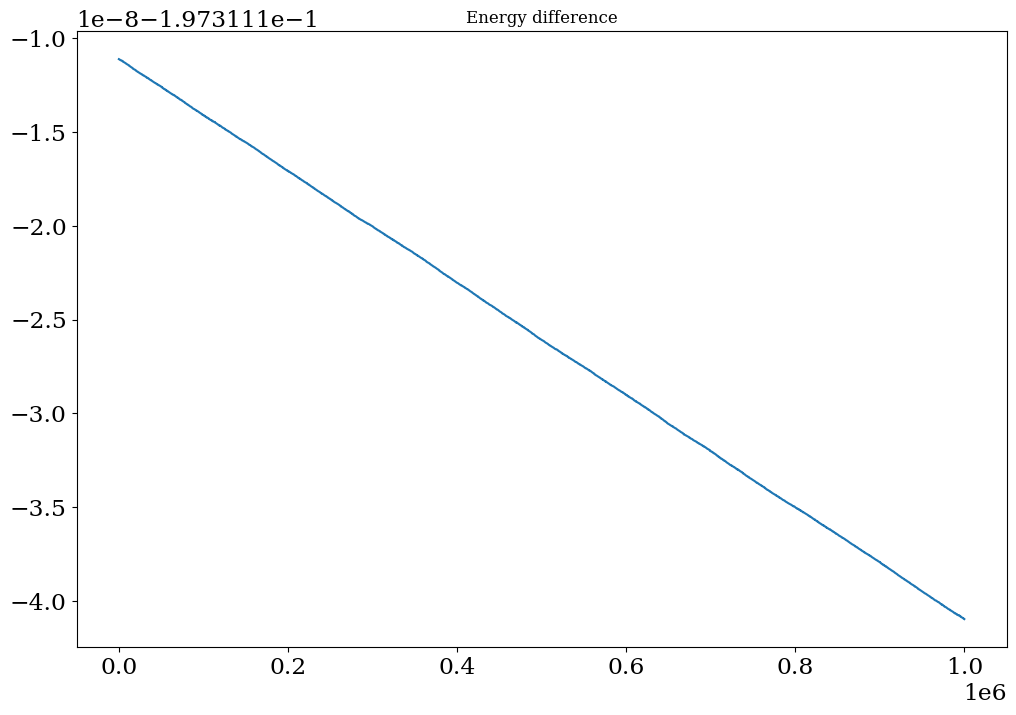

In [105]:
plt.plot(np.arange(0.0, tf, tau)[:-1], lyaps1[2])
plt.title("Energy difference")

In [106]:
np.mean(lyaps1[0][-10000:])

8.079934031287518e-05

Text(0.5, 1.0, 'Time Evolution of Lyapunov Exponents ')

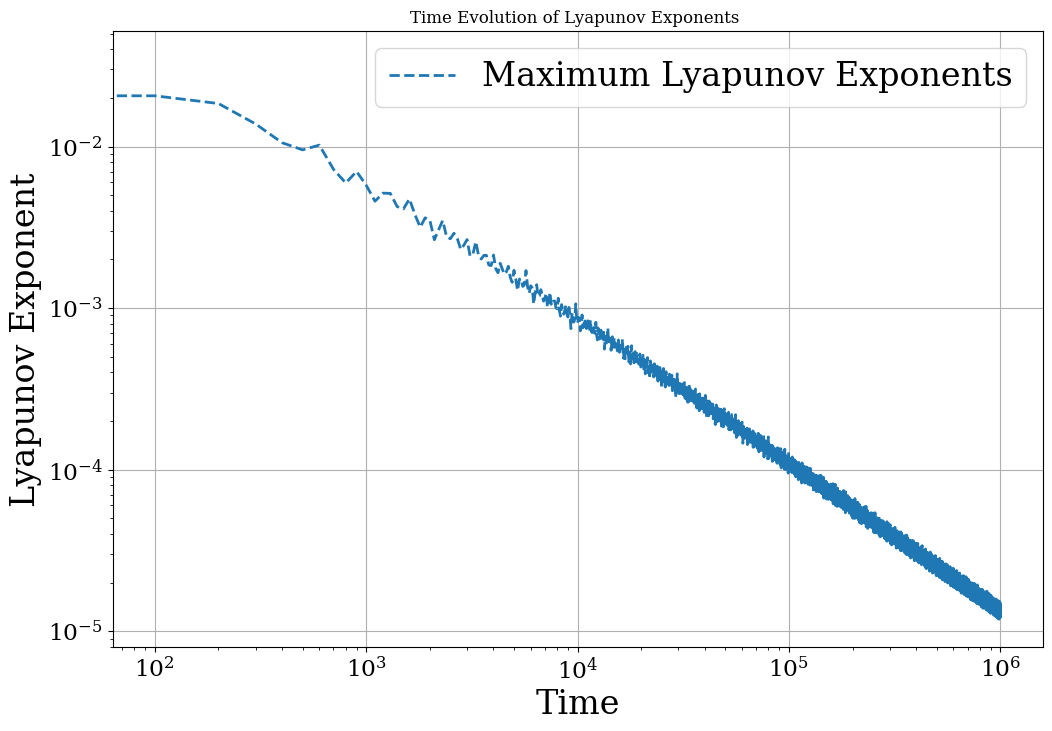

In [107]:
plt.figure()
plt.plot(
    np.arange(0.0, tf, tau)[:-2],
    lyaps1[0][:-1],
    label="Maximum Lyapunov Exponents",
    linewidth=2,
    linestyle="--",
)
ax = plt.gca()
ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)
plt.xlabel("Time")
plt.ylabel("Lyapunov Exponent")
plt.legend()
# plt.xlim(1e4,1e6)
plt.grid(True)
plt.title("Time Evolution of Lyapunov Exponents ")
# plt.show()

In [108]:
@nb.cfunc(lsoda_sig)
def faster_evolve(t, u, du, p):
    """
    Function for solving Differential Equation
    Args:
        t (float): Time Step
        x (np.ndarray): Shape (n,)

    Returns:
        Output (np.ndarray): Shape (n,)
    """
    # w,z, phi,pw,pz,pphi=x
    p_ = nb.carray(p, (1,))
    alpha = p_[0]
    du[0] = u[3]
    du[1] = u[4]
    du[2] = L / (mu * u[0] ** 2)

    du[3] = -mu * (
        -(L**2) / (mu**2 * u[0] ** 3) + M * u[0] / ((u[0] ** 2 + u[1] ** 2) ** (3 / 2))
    )
    du[4] = -mu * (
        M * u[1] / ((u[0] ** 2 + u[1] ** 2) ** (3 / 2)) + alpha * np.tanh(u[1] / z0)
    )
    du[5] = 0.0

funcptr = faster_evolve.address

In [109]:
@nb.njit(
    nb.float64[:](
        nb.float64,
        nb.float64[:, :],
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
    ),
    parallel=True,
)
def hplus(t, dH, R, mu, Theta, Psi, alpha):
    """

    Args:
        t ([float]): Time, not needed in this function
        dH ([ndarray]): Solution of differential Equation at various time steps, shape (n,6)
        R ([float]): Distance of observer and the system
        mu ([float]): Mass of the particle
        Theta ([float]): Location of the observer
        Psi ([float]): Location of the observer
        alpha ([float]): Parameter of the theory

    Returns:
        Expression of hplus ([ndarray]) at various time: Shape (n,6)
    """
    # Compute the hplus expression using NumPy

    r, zc, phi, pr, pzc, pphi = (
        dH[:, 0],
        dH[:, 1],
        dH[:, 2],
        dH[:, 3],
        dH[:, 4],
        dH[:, 5],
    )
    dr_dt = pr / mu
    dzc_dt = pzc / mu
    dPhi_dt = L / (mu**2 * r**2)
    d2r_dt2 = -(-(L**2) / (mu**2 * r**3) + M * r / ((r**2 + zc**2) ** (3 / 2)))
    d2zc_dt2 = -(M * zc / ((r**2 + zc**2) ** (3 / 2)) + alpha * np.tanh(zc / z0))
    d2Phi_dt2 = 0.0

    expression = (
        (1 / (2 * R))
        * mu
        * (
            -2
            * np.sin(Theta) ** 2
            * (dr_dt**2 - 2 * dzc_dt**2 + r * d2r_dt2 - 2 * zc * d2zc_dt2)
            + (3 + np.cos(2 * Theta))
            * np.sin(2 * phi)
            * (
                np.sin(2 * Psi) * (dr_dt**2 + r * (-2 * r * dPhi_dt**2 + d2r_dt2))
                - np.cos(2 * Psi) * r * (4 * dr_dt * dPhi_dt + r * d2Phi_dt2)
            )
            + (3 + np.cos(2 * Theta))
            * np.cos(2 * phi)
            * (
                np.cos(2 * Psi) * (dr_dt**2 + r * (-2 * r * dPhi_dt**2 + d2r_dt2))
                + r * np.sin(2 * Psi) * (4 * dr_dt * dPhi_dt + r * d2Phi_dt2)
            )
            + 2
            * np.sin(2 * Theta)
            * np.sin(phi)
            * (
                -np.sin(Psi)
                * (
                    2 * dr_dt * dzc_dt
                    + zc * d2r_dt2
                    + r * (-zc * dPhi_dt**2 + d2zc_dt2)
                )
                + np.cos(Psi)
                * (2 * (zc * dr_dt + r * dzc_dt) * dPhi_dt + r * zc * d2Phi_dt2)
            )
            - 2
            * np.cos(phi)
            * np.sin(2 * Theta)
            * (
                np.cos(Psi)
                * (
                    2 * dr_dt * dzc_dt
                    + zc * d2r_dt2
                    + r * (-zc * dPhi_dt**2 + d2zc_dt2)
                )
                + np.sin(Psi)
                * (2 * (zc * dr_dt + r * dzc_dt) * dPhi_dt + r * zc * d2Phi_dt2)
            )
        )
    )

    return expression

In [110]:
# @snoop
@nb.njit(
    nb.float64[:](
        nb.float64,
        nb.float64[:, :],
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
    ),
    parallel=True,
)
# Define the Python function 'hcross'
def hcross(t, dH, R, mu, Theta, Psi, alpha):
    """

    Args:
        t ([float]): Time, not needed in this function
        dH ([ndarray]): Solution of differential Equation at various time steps, shape (n,6)
        R ([float]): Distance of observer and the system
        mu ([float]): Mass of the particle
        Theta ([float]): Location of the observer
        Psi ([float]): Location of the observer
        alpha ([float]): Parameter of the theory

    Returns:
        Expression of hcross ([ndarray]) at various time: Shape (n,6)
    """
    # Compute the hcross expression using NumPy

    r, zc, phi, pr, pzc, pphi = (
        dH[:, 0],
        dH[:, 1],
        dH[:, 2],
        dH[:, 3],
        dH[:, 4],
        dH[:, 5],
    )
    dr_dt = pr
    dzc_dt = pzc
    dPhi_dt = L / (mu * r**2)
    d2r_dt2 = -mu * (-(L**2) / (mu**2 * r**3) + M * r / ((r**2 + zc**2) ** (3 / 2)))
    d2zc_dt2 = -mu * (M * zc / ((r**2 + zc**2) ** (3 / 2)) + alpha * np.tanh(zc / z0))
    d2Phi_dt2 = 0.0

    # Compute the expression using NumPy
    expression = (
        (1 / R)
        * 2
        * mu
        * (
            -np.cos(Theta) * np.sin(2 * (Psi - phi)) * dr_dt**2
            + 2
            * dr_dt
            * (
                np.sin(Theta) * np.sin(Psi - phi) * dzc_dt
                + (
                    2 * np.cos(Theta) * np.cos(2 * (Psi - phi)) * r
                    - np.cos(Psi - phi) * np.sin(Theta) * zc
                )
                * dPhi_dt
            )
            + np.cos(Theta)
            * r
            * (
                np.sin(2 * (Psi - phi)) * (2 * r * dPhi_dt**2 - d2r_dt2)
                + np.cos(2 * (Psi - phi)) * r * d2Phi_dt2
            )
            + np.sin(Theta)
            * (
                np.sin(Psi - phi) * zc * d2r_dt2
                - r
                * (
                    2 * np.cos(Psi - phi) * dzc_dt * dPhi_dt
                    + np.sin(Psi - phi) * (zc * dPhi_dt**2 - d2zc_dt2)
                    + np.cos(Psi - phi) * zc * d2Phi_dt2
                )
            )
        )
    )

    return expression

In [111]:
# Solve the system
usol10, success = lsoda(
    funcptr, ics, tm2, data=np.array((alpha)), atol=1e-12, rtol=1e-12
)

In [112]:
hp10 = hplus(0, usol10, R, mu, Theta, Psi, alpha)  # hplus
hc10 = hcross(0, usol10, R, mu, Theta, Psi, alpha)  # hcross

Text(0.5, 0, 't')

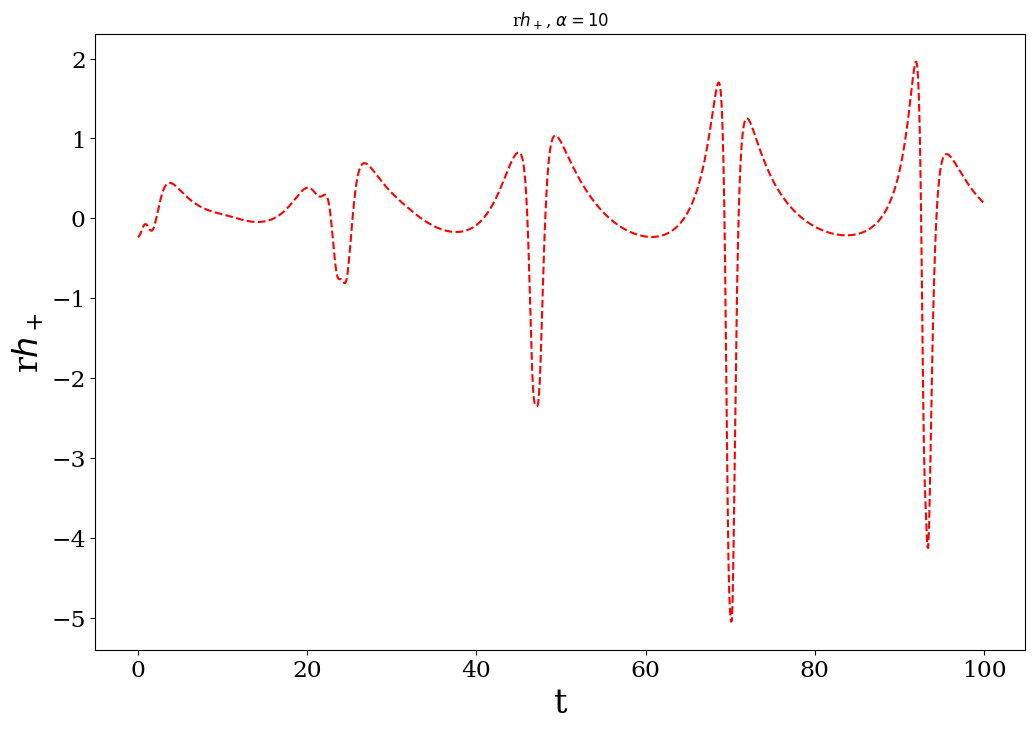

In [113]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2[:1000], R * hp10[:1000], "r--")
plt.title(r"r$h_+$, $\alpha=10$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

Text(0.5, 0, 't')

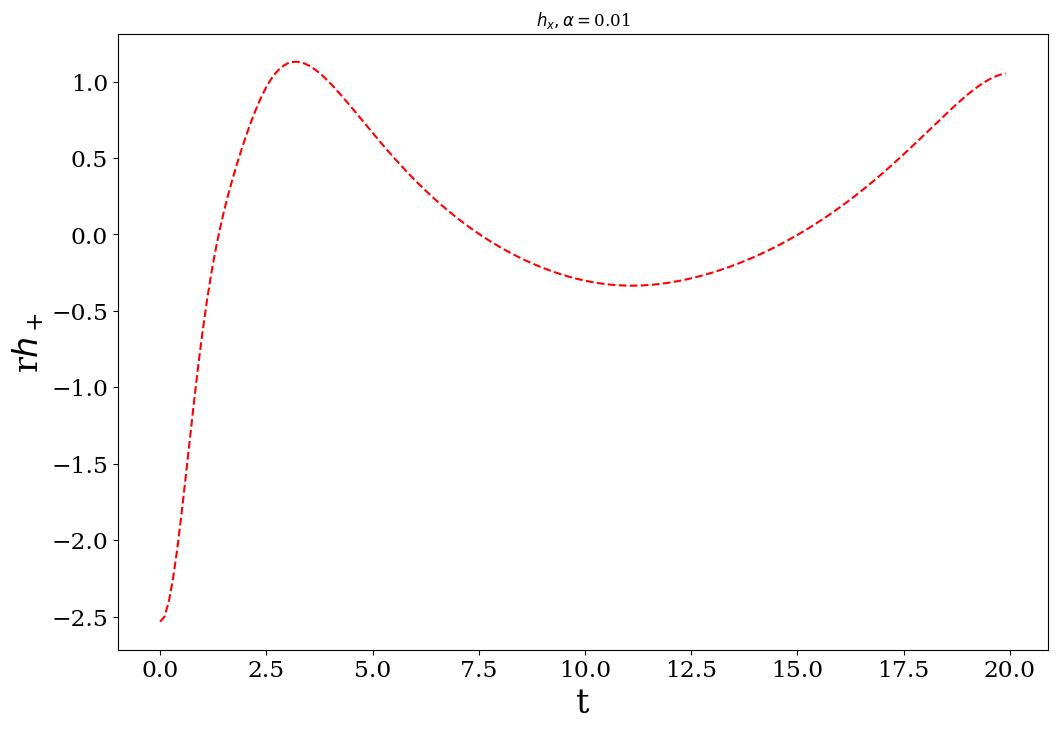

In [114]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2[:200], R * hc10[:200], "r--")
plt.title(r"$h_x, \alpha=${0}".format(alpha))
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

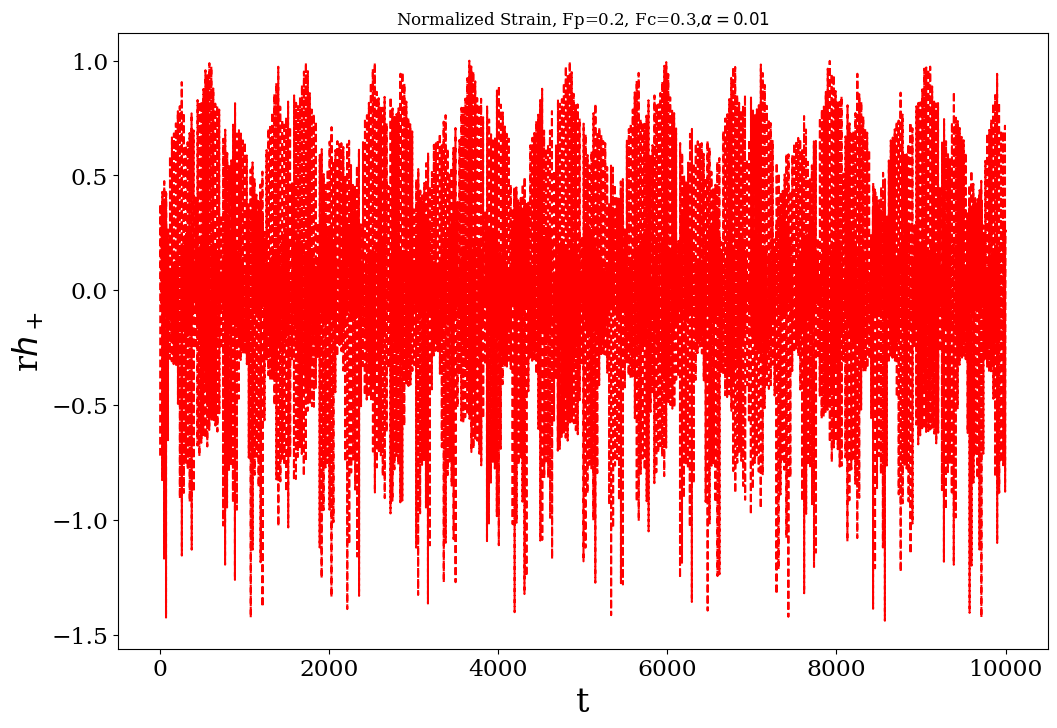

In [115]:
norm_strain = (R * (Fp * hp10 + Fc * hc10)) / np.max((R * (Fp * hp10 + Fc * hc10)))

fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2, norm_strain, "r--")
plt.title(r"Normalized Strain, Fp=0.2, Fc=0.3,$\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")
plt.savefig("Normalized_Strain.png",dpi=300)

In [116]:
def de_dw(t, hp, hc):
    """
    Calculate dE/dw

    Args:
        t (ndarray): Time array between which to calculate the FFT, Shape: (n,)
        hp (ndarray): hplus array, Shape: (n,)
        hc (ndarray): hcross array, Shape: (n,)

    Returns:
        dEdw (ndarray): dEdw, shape(n//2,)
        df (ndarray): Fourier Transform Frequencies, shape(n//2,)
    """
    # window=np.hanning(t.size)
    fhp = np.fft.fft(hp, norm="ortho")
    fhc = np.fft.fft(hc, norm="ortho")
    N = len(fhc)

    dt = t[1] - t[0]
    # df=sp.fft.fftfreq(len(fhp),dt)[1:N//2]
    df = (np.arange(len(t)) / (dt * N))[: N // 2]
    # const=(3e8)**3/(4*6.674e-11)

    E = (np.abs(fhp) ** 2 + np.abs(fhc) ** 2)[: N // 2]
    dEdw = (E * df**2) * R**2

    return dEdw, df

In [117]:
E10, f10 = de_dw(tm2, hp10, hc10)
# * For alpha

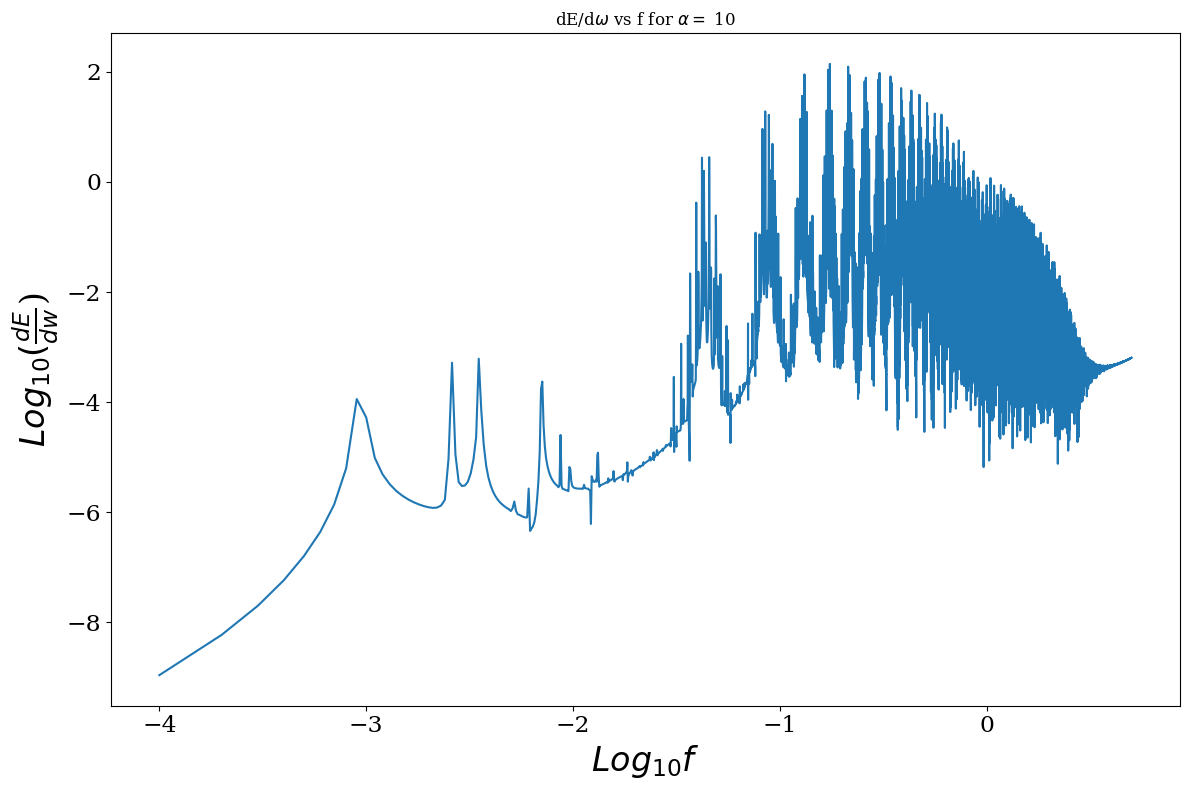

In [118]:
plt.plot(np.log10(f10[1:]), np.log10(E10[1:]))
plt.title(r"dE/d$\omega$ vs f for $\alpha=$ 10")
plt.ylabel(r"$Log_{10}(\frac{dE}{dw}$)")
plt.xlabel(r"$Log_{10}f$")
plt.tight_layout()
plt.savefig("Energy_density.png",dpi=300)

In [119]:
#! Noise + Signal

noise = np.random.normal(0.0, 1.0, len(hp10))  # * Normally distributed Random Noise

nhp10 = hp10 + noise  # *Adding noise to signals
nhc10 = hc10 + noise

# nhp10=nhp10/np.max(nhp10)
# nhc10 = nhc10 / np.max(nhc10)

Text(0.5, 0, 't')

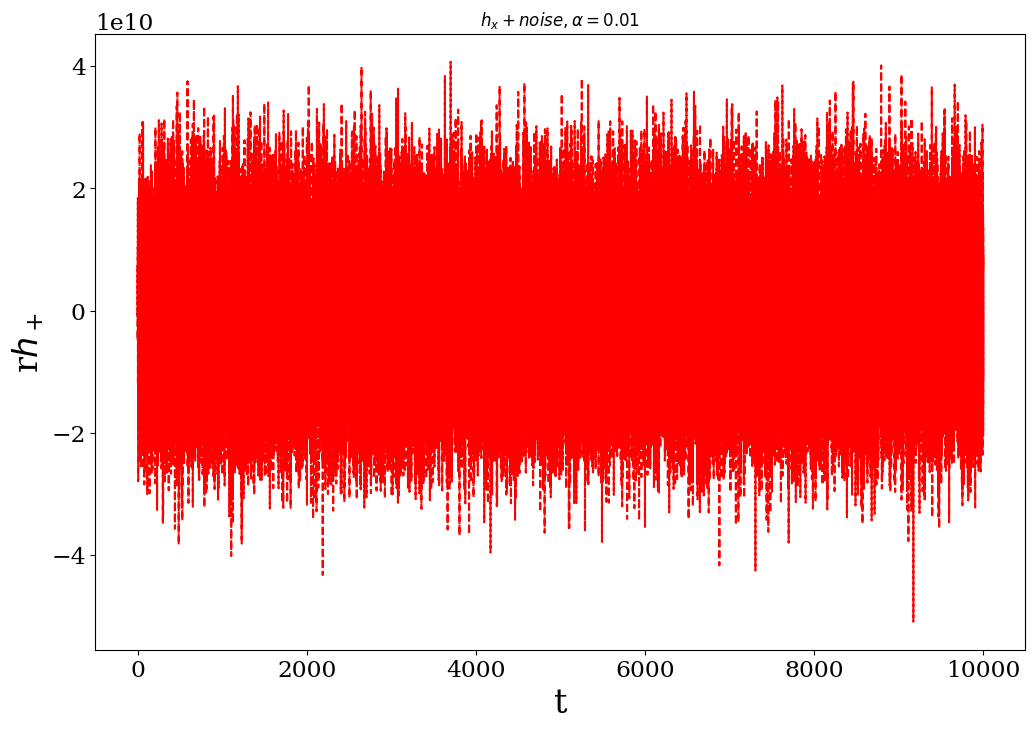

In [120]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2, R * nhc10, "r--")
plt.title(r"$h_x+ noise, \alpha=0.01$ ")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

Text(0.5, 0, 't')

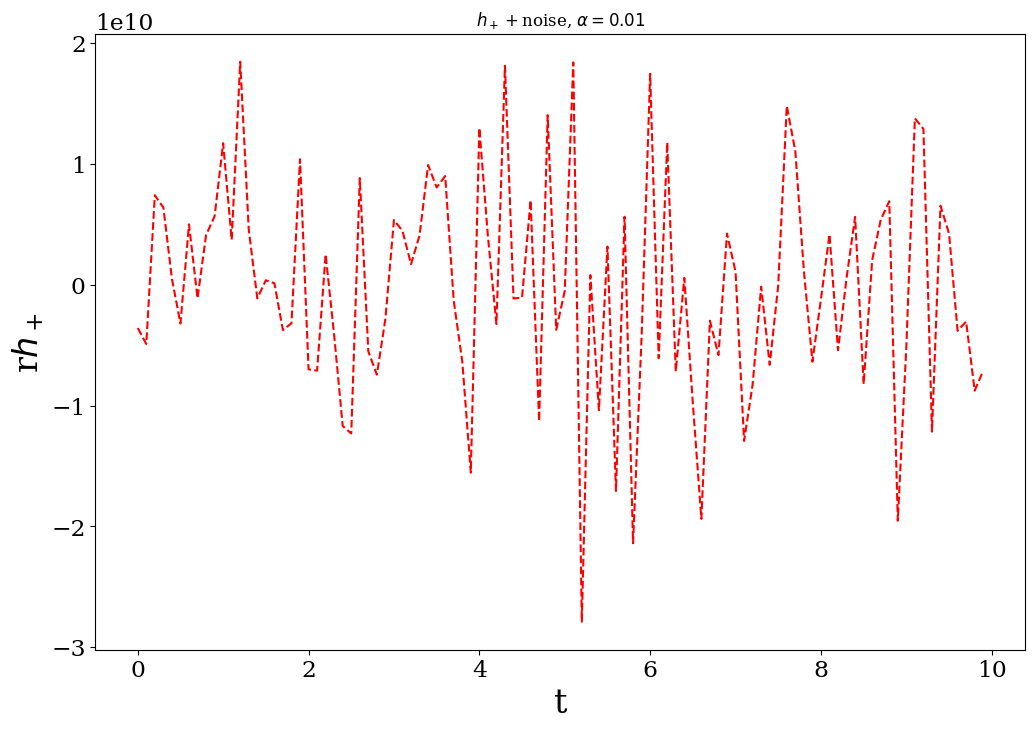

In [121]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2[:100], R * nhp10[:100], "r--")
plt.title(r"$h_++$noise, $\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

In [122]:
norm_strain_noise = (R * (Fp * nhp10 + Fc * nhc10)) / np.max((R * (Fp * nhp10 + Fc * nhc10)))

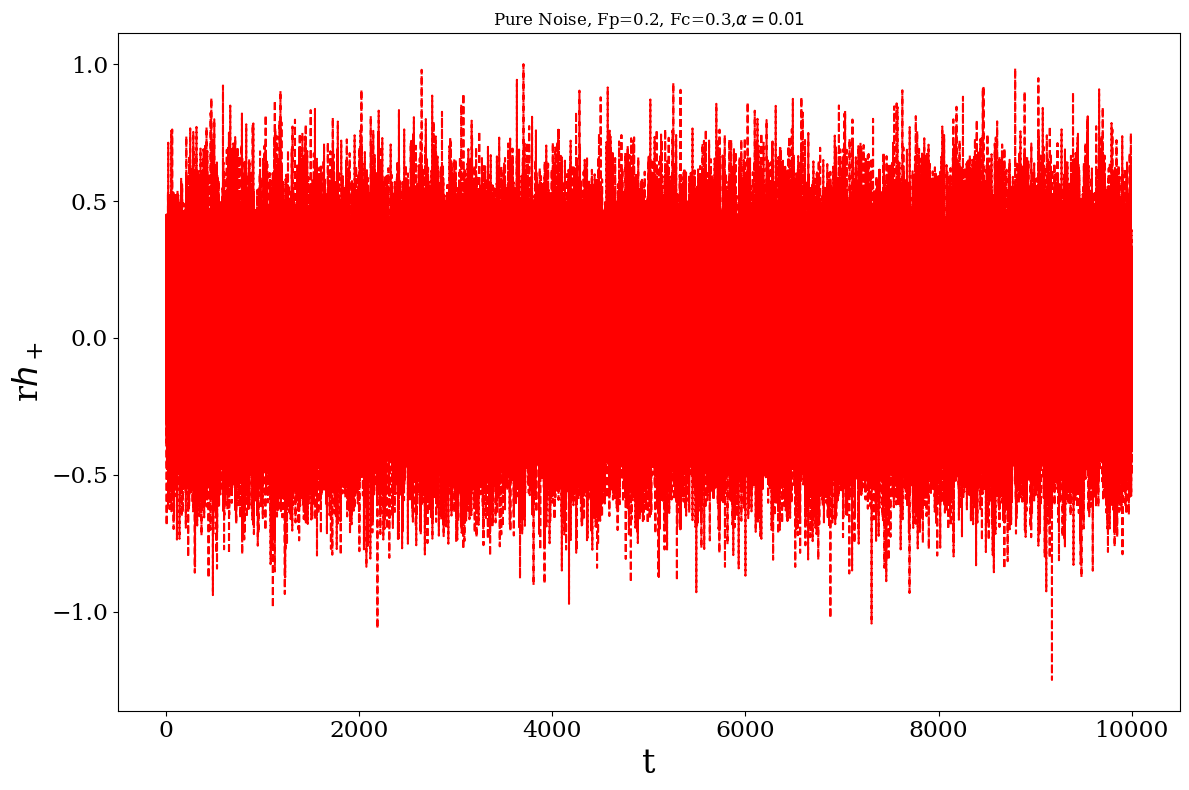

In [123]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2, R *noise/(np.max(R*noise)), "r--")
plt.title(r"Pure Noise, Fp=0.2, Fc=0.3,$\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")
plt.tight_layout()
plt.savefig("pure_noise.png",dpi=300)

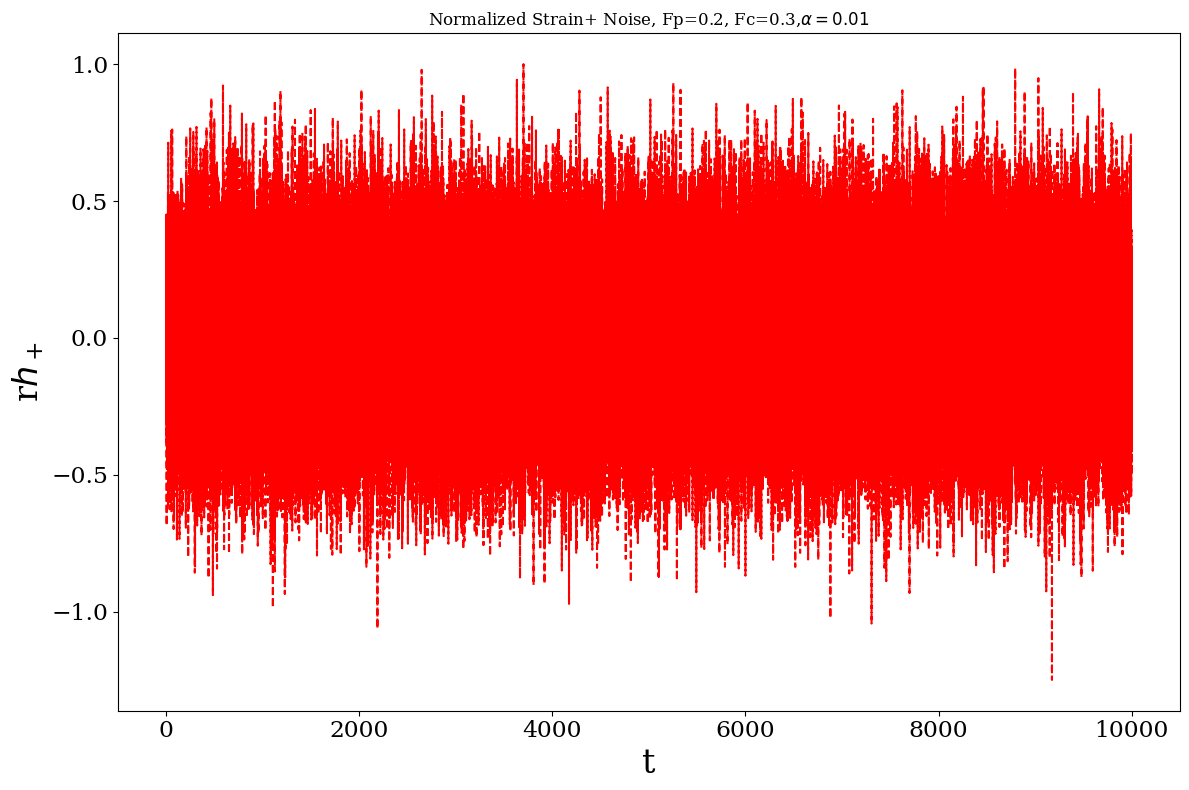

In [124]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2,norm_strain_noise, "r--")
plt.title(r"Normalized Strain+ Noise, Fp=0.2, Fc=0.3,$\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")
plt.tight_layout()
plt.savefig("strain_noise.png",dpi=300)

In [125]:
#! Get the energy spectra for noise with signals
NE10, nf10 = de_dw(tm2, nhp10, nhc10)

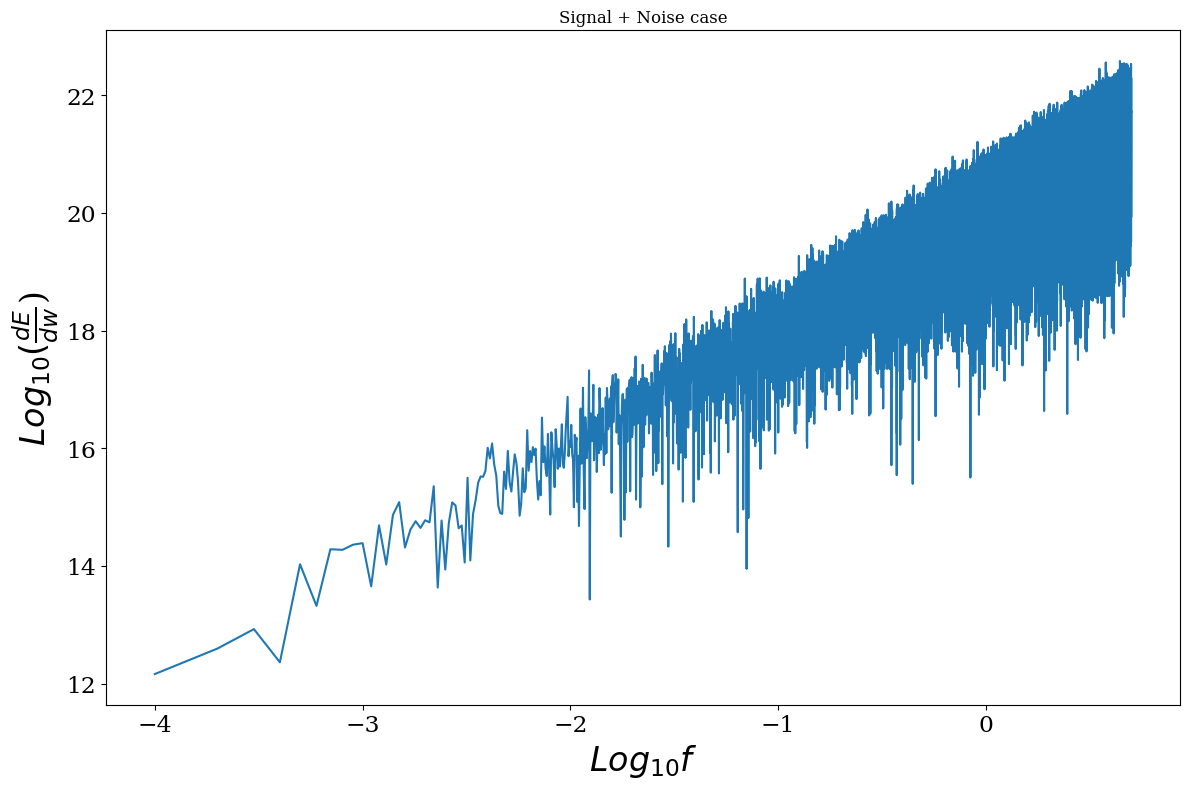

In [126]:
fig, ax = plt.subplots(nrows=1, ncols=1)
# fig.set_size_inches(18.5, 10.5)
ax.plot(np.log10(nf10[1:]), np.log10(NE10[1:]))

# fig.suptitle(r"dE/d$\omega$ vs f for $\alpha=10.$")
ax.set_title("Signal + Noise case")

plt.ylabel(r"$Log_{10}(\frac{dE}{dw}$)")
plt.xlabel(r"$Log_{10}f$")
plt.tight_layout()
plt.savefig("psd_signal_noise.png",dpi=300)

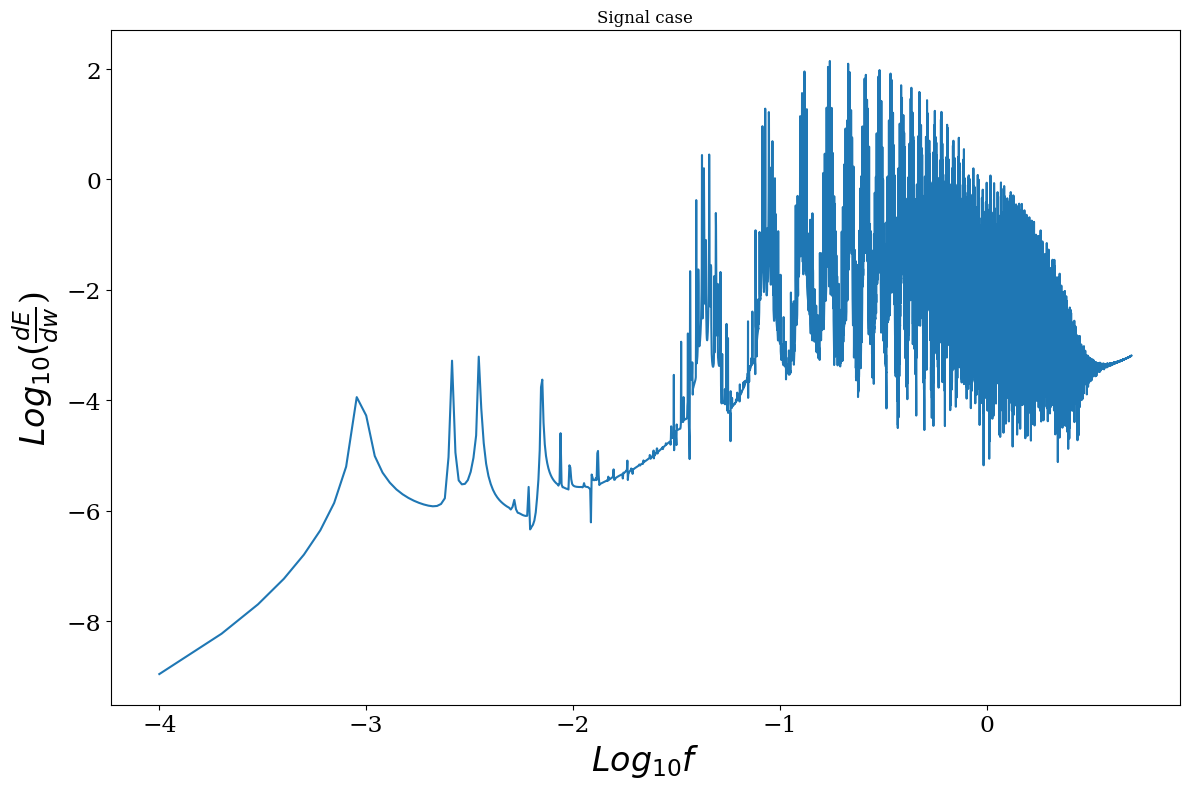

In [127]:
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(np.log10(f10[1:]), np.log10(E10[1:]))
ax.set_title("Signal case")
plt.ylabel(r"$Log_{10}(\frac{dE}{dw}$)")
plt.xlabel(r"$Log_{10}f$")
plt.tight_layout()
plt.savefig("psd_signal.png", dpi=300)

In [41]:
import pycbc.psd 
import pycbc.noise
from pycbc.types import TimeSeries, FrequencySeries
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.filter import matched_filter

import legwork
import astropy
import astropy.units as u
from importlib import resources
import os

/home/abhishek/GWProject/gwpython/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [42]:
# Parameters
sample_rate = 4096  # Hz
duration = 16  # seconds
template_duration = 1.6  # seconds

In [43]:
# Generate noise
delta_f = 1.0 / duration
flen = int(sample_rate / delta_f) // 2 + 1
# psd = pycbc.psd.analytical_space.analytical_psd_lisa_tdi_AE_confusion(
#     flen, delta_f, 15.0, tdi="2.0"
# )

psd = pycbc.psd.analytical_space.analytical_psd_tianqin_tdi_XYZ(
    flen, delta_f, 1000.0, tdi="2.0"
)
# psd.data=psd.data

# psd = pycbc.psd.analytical_space.averaged_fplus_sq_approximated(
#     np.linspace(0.0, 1000, flen), len_arm=2500000000.0
# )
# delta_f_ = np.linspace(0.0, 1000, flen)[1] - np.linspace(0.0, 1000, flen)[0]
# psd = pt.frequencyseries.FrequencySeries(
#     psd,delta_f_)

# psd = pycbc.psd.analytical_space.confusion_fit_lisa(
#     flen, delta_f, 15., duration=1.0
# )

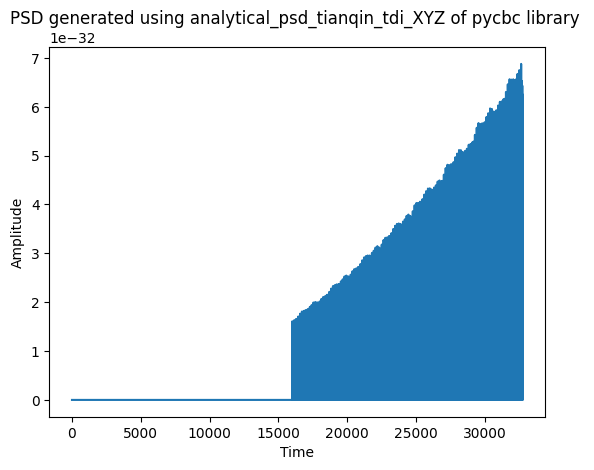

In [44]:
plt.plot(psd)
plt.title("PSD generated using analytical_psd_tianqin_tdi_XYZ of pycbc library ")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.savefig("psd.png")

In [45]:
noise_ts = pycbc.noise.gaussian.noise_from_psd(
    int(16 * sample_rate), delta_t=1.0 / sample_rate, psd=psd, seed=100
)
# noise_ts.data = noise_ts.data * 1e5

In [46]:
noise_ts.shape

(65536,)

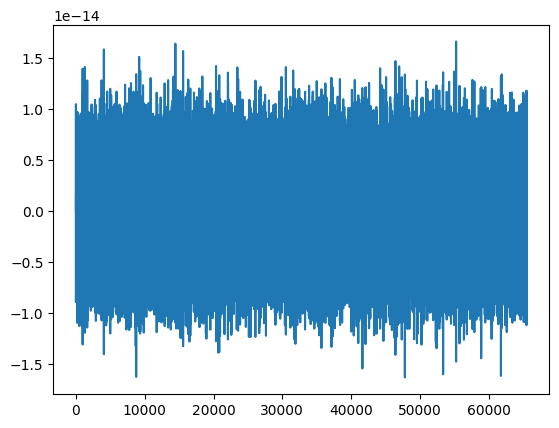

In [47]:
plt.plot(noise_ts)

In [48]:
# template = hp10[:10000]/1e5
template = TimeSeries(
    hp10[:10000]/1e5,
    delta_t=1.0 / sample_rate,
)

In [49]:
# Insert the template into the noise
start_time = 4  # Insert the template at 4 seconds
insert_start_index = int(start_time * sample_rate)
noise_ts.data[insert_start_index : insert_start_index + len(template)] += template.data

Text(0.5, 1.0, 'Signal embedded into noise of given PSD')

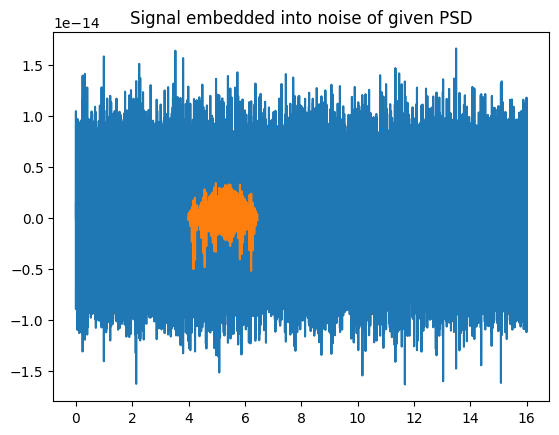

In [50]:
plt.plot(noise_ts.sample_times,noise_ts)
plt.plot(
    noise_ts.sample_times.data[insert_start_index: insert_start_index + len(template)],\
    template
)
plt.title("Signal embedded into noise of given PSD")
# plt.savefig("signoies.png")
# plt.plot()

In [51]:
data= noise_ts.to_timeseries()
template_new = hp10[:10000]/1e5
# template_new= np.random.normal(0.,1.,10000)*1e-15
time=np.arange(0.0,16.,delta_f)
zero_pad = np.zeros(data.data.size - template_new.size)
template_padded = np.append(template_new, zero_pad)
template_padded= TimeSeries(template_padded,delta_t=1/sample_rate)

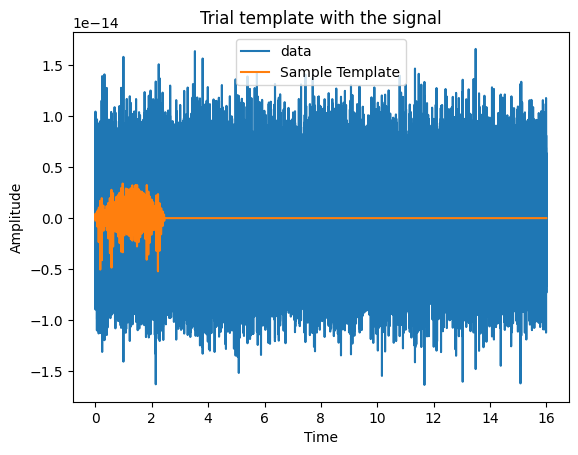

In [52]:
plt.plot(noise_ts.sample_times,data,label="data")
plt.plot(
    noise_ts.sample_times.data,
    template_padded,
    label="Sample Template",
)
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.title("Trial template with the signal")
plt.legend()
# plt.savefig("GWdata_signal.png")

In [53]:
# snr= pycbc.filter.matched_filter(template_padded,data,psd=psd,low_frequency_cutoff=100)

In [54]:
# plt.plot(snr.sample_times, abs(snr))

In [55]:
data_fft = np.fft.fft(data)
template_fft = np.fft.fft(template_padded)

In [56]:
# # Estimate PSD from the data
# psd_estimated = data.psd(4)
# psd_estimated = interpolate(psd_estimated, delta_f)
# psd_estimated = inverse_spectrum_truncation(
#     psd_estimated, int(4 * sample_rate), low_frequency_cutoff=100
# )

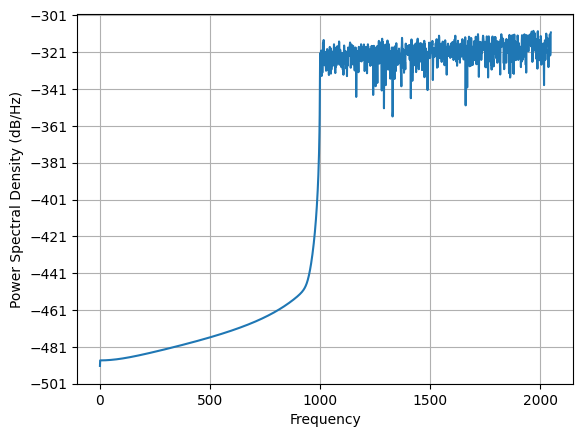

In [57]:
# -- Calculate the PSD of the data
fs=4096
power_data, freq_psd = plt.psd(data[15 * fs :], Fs=fs, NFFT=fs, visible=True)
# plt.title("PSD of pure Gaussian noise")
# plt.savefig("noisepsd.png")
# -- Interpolate to get the PSD values at the needed frequencies
datafreq = np.fft.fftfreq(data.data.size) * fs
power_vec = np.interp(datafreq, freq_psd, power_data)


In [58]:
# -- Calculate the matched filter output
optimal = data_fft * template_fft.conjugate() / power_vec
optimal_time = 2 * np.fft.ifft(optimal)

In [59]:
# -- Normalize the matched filter output
df = np.abs(datafreq[1] - datafreq[0])
sigmasq = 2 * (template_fft * template_fft.conjugate() / power_vec).sum()*df
sigma = np.sqrt(np.abs(sigmasq))
SNR = abs(optimal_time) / (sigma)

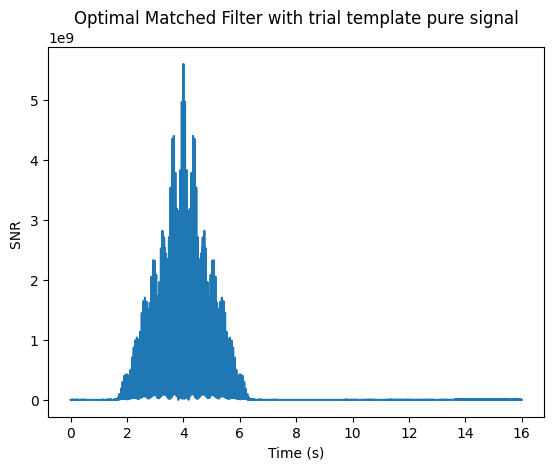

In [60]:
# -- Plot the result
plt.figure()
plt.plot(noise_ts.sample_times,SNR)
plt.title("Optimal Matched Filter with trial template pure signal")
plt.xlabel("Time (s)")
plt.ylabel("SNR ")
plt.savefig("snr_with_signal.png")

1118.6176


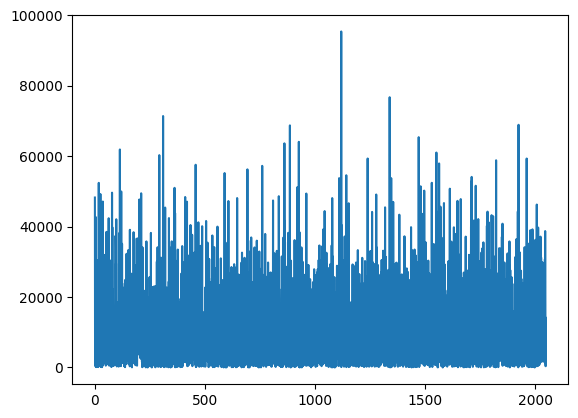

In [61]:
s_da_ = np.random.normal(0.0, 1.0, 10000)
fft = np.fft.fft(s_da_)
freqs = np.fft.fftfreq(len(s_da_), 1 / sample_rate)
# Compute the power spectrum
power = np.abs(fft)**2
print(freqs[np.argmax(power)])

plt.plot(freqs[: len(freqs) // 2], power[: len(freqs) // 2])

In [62]:
hp10.shape

(100000,)

In [71]:
import legwork
import astropy
import astropy.units as u
from importlib import resources
import os

In [66]:
f = np.linspace(1e-4, 0.99e-2, 100000)

fstar = astropy.constants.c.value / (2 * np.pi * L)
Sa = 1e-30  
Sx = 1e-24 
psd = 10 / (3 * L**2) * (4 * Sa / (2 * np.pi * f)**4 * (1 + (1e-4 / f)) + Sx) \
    * (1 + 0.6 * (f / fstar)**2)
# f = np.linspace(1e-4, 0.9e-2, 50000)
t_obs=4.0
# parameters from Robson+ 2019 Table 1
lengths = np.array([0.5, 1.0, 2.0, 4.0]) 
alpha = [0.133, 0.171, 0.165, 0.138]
beta = [243.0, 292.0, 299.0, -221.0]
kappa = [482.0, 1020.0, 611.0, 521.0]
gamma = [917.0, 1680.0, 1340.0, 1680.0]
fk = [2.58e-3, 2.15e-3, 1.73e-3, 1.13e-3]

# find index of the closest length to inputted observation time
ind = np.abs(t_obs - lengths).argmin()

confusion_noise = 9e-45 * f**(-7 / 3.) * np.exp(-f**(alpha[ind]) + beta[ind]
                                                * f * np.sin(kappa[ind] * f))\
    * (1 + np.tanh(gamma[ind] * (fk[ind] - f))) **(-1)

# confusion_noise = (
#     9e-45
#     * f ** (-7 / 3.0)
#     * np.exp(-(f ** (alpha[ind])) + beta[ind] * f * np.sin(kappa[ind] * f))
#     * (1 + np.exp(-gamma[ind] * (fk[ind] - f))) ** (-1)
# )

# psd=psd+confusion_noise

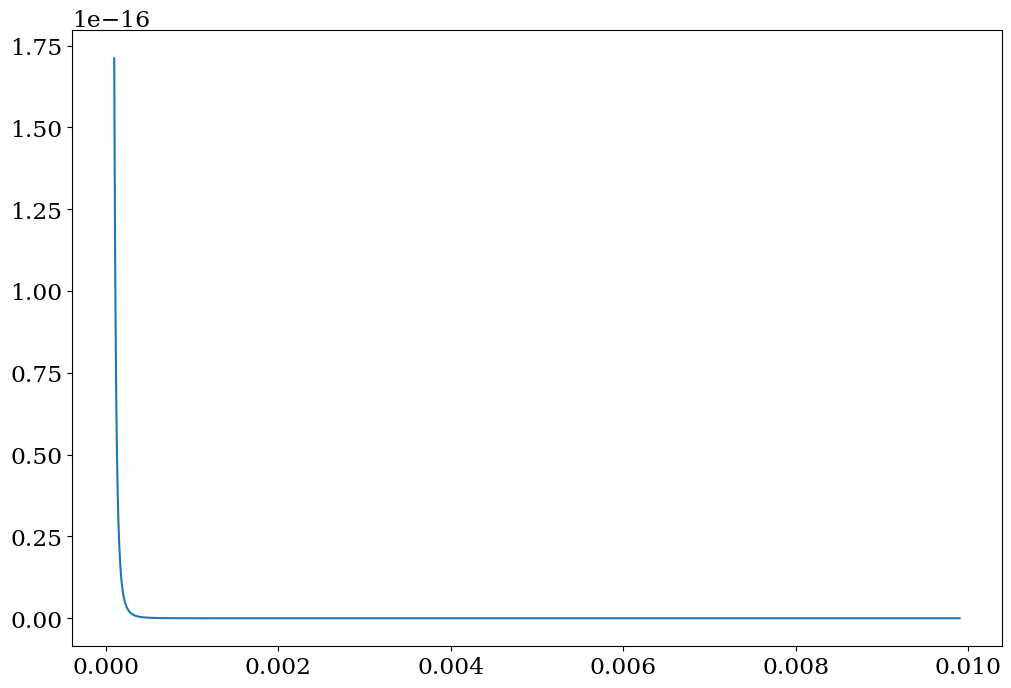

In [160]:
plt.plot(f,psd)
# plt.plot(confusion_noise)

In [161]:
fpsd=FrequencySeries(psd,1/16.)

In [162]:
noise_ts = pycbc.noise.gaussian.noise_from_psd(
    int(16.*sample_rate), delta_t=fpsd.delta_t, psd=fpsd, seed=100
)

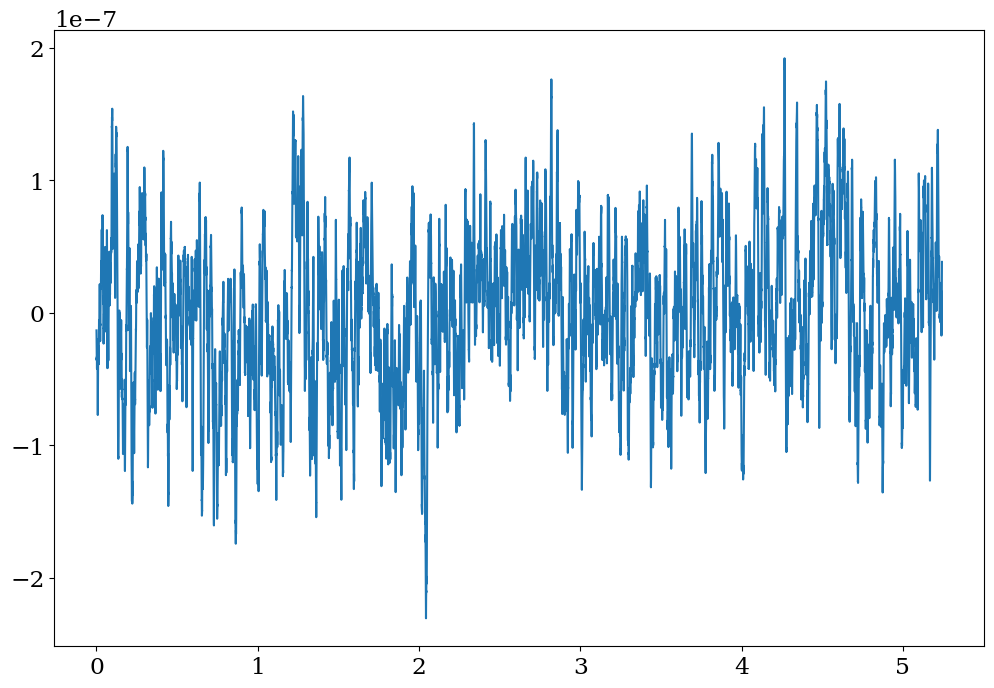

In [163]:
plt.plot(noise_ts.sample_times,noise_ts)

In [164]:
noise_ts.duration

5.242932429324293

In [168]:
template = TimeSeries(
    hp10[:10000]*1e2 ,
    delta_t=1.0 / sample_rate,
)

In [169]:
# Insert the template into the noise
start_time = 4  # Insert the template at 4 seconds
insert_start_index = int(start_time * sample_rate)
noise_ts.data[insert_start_index : insert_start_index + len(template)] += template.data

Text(0.5, 1.0, 'Signal embedded into noise of given PSD')

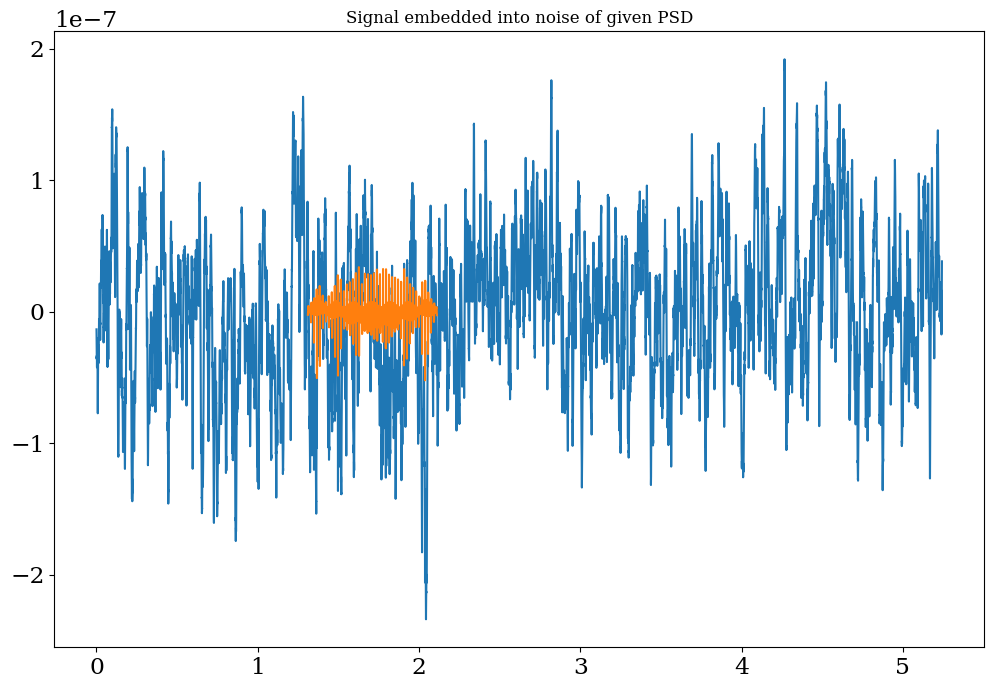

In [170]:
plt.plot(noise_ts.sample_times, noise_ts)
plt.plot(
    noise_ts.sample_times.data[insert_start_index : insert_start_index + len(template)],
    template,
)
plt.title("Signal embedded into noise of given PSD")
# plt.savefig("signoies.png")
# plt.plot()

In [195]:
data = noise_ts.to_timeseries()
# template_new = hp10[:10000] *1e2
template_new= np.random.normal(0.,1.,10000)*1e-8
time = np.arange(0.0, 16.0, delta_f)
zero_pad = np.zeros(data.data.size - template_new.size)
template_padded = np.append(template_new, zero_pad)
template_padded = TimeSeries(template_padded, delta_t=1 / sample_rate)

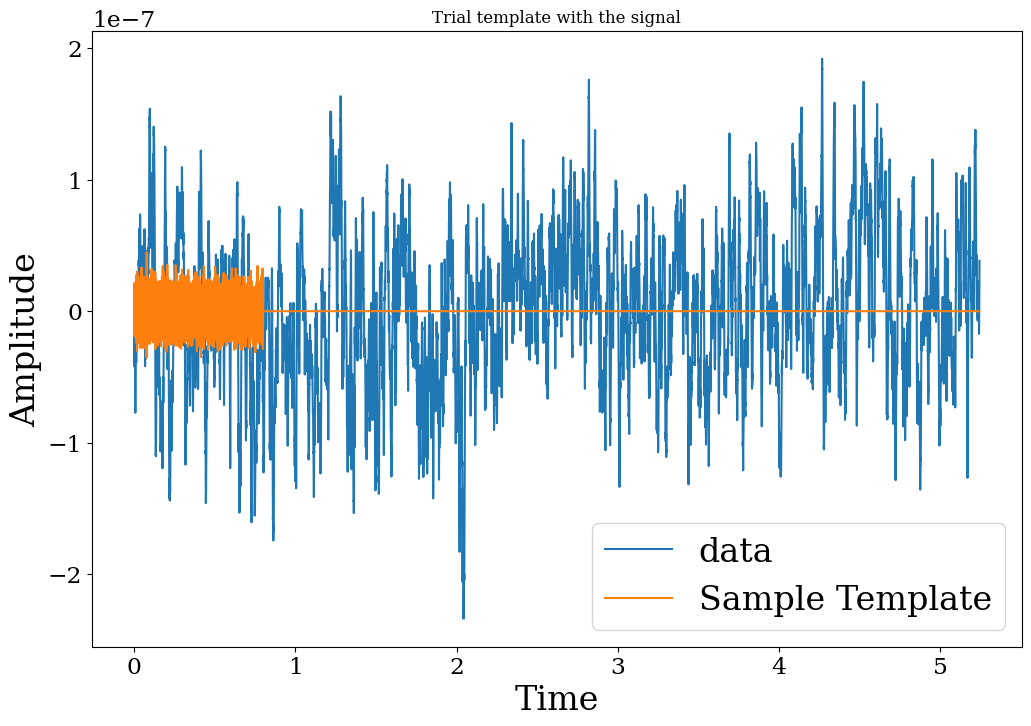

In [196]:
plt.plot(noise_ts.sample_times, data, label="data")
plt.plot(
    noise_ts.sample_times.data,
    template_padded,
    label="Sample Template",
)
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.title("Trial template with the signal")
plt.legend()
# plt.savefig("GWdata_signal.png")

In [197]:
data_fft = np.fft.fft(data)
template_fft = np.fft.fft(template_padded)

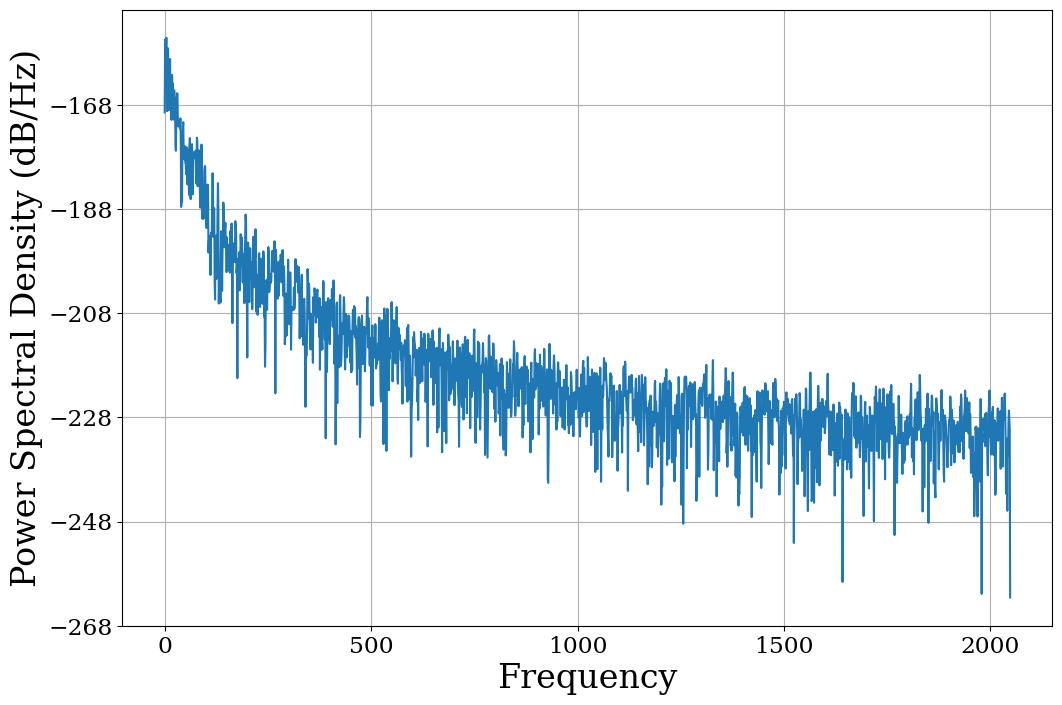

In [198]:
# -- Calculate the PSD of the data
fs = 4096
power_data, freq_psd = plt.psd(data[15 * fs :], Fs=fs, NFFT=fs, visible=True)
# plt.title("PSD of pure Gaussian noise")
# plt.savefig("noisepsd.png")
# -- Interpolate to get the PSD values at the needed frequencies
datafreq = np.fft.fftfreq(data.data.size) * fs
power_vec = np.interp(datafreq, freq_psd, power_data)

In [199]:
# -- Calculate the matched filter output
optimal = data_fft * template_fft.conjugate() / power_vec
optimal_time = 2 * np.fft.ifft(optimal)

In [200]:
# -- Normalize the matched filter output
df = np.abs(datafreq[1] - datafreq[0])
sigmasq = 2 * (template_fft * template_fft.conjugate() / power_vec).sum() * df
sigma = np.sqrt(np.abs(sigmasq))
SNR = abs(optimal_time) / (sigma)

Text(0, 0.5, 'SNR ')

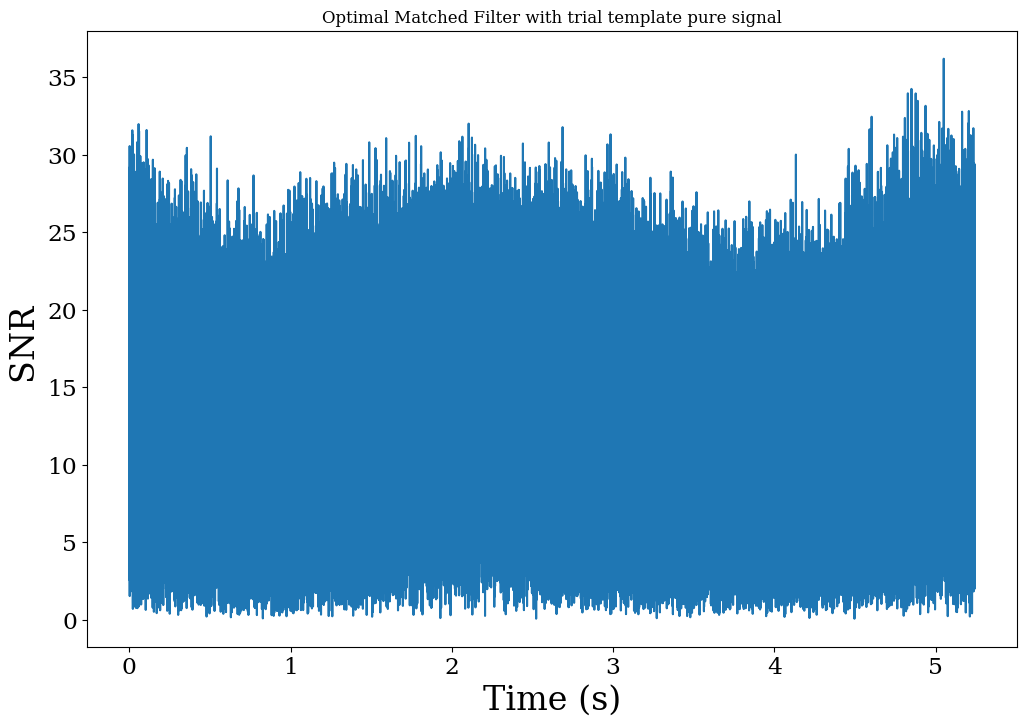

In [201]:
# -- Plot the result
plt.figure()
plt.plot(noise_ts.sample_times, SNR)
plt.title("Optimal Matched Filter with trial template pure signal")
plt.xlabel("Time (s)")
plt.ylabel("SNR ")
# plt.savefig("snr_with_signal.png")

### New PSD

In [43]:
import legwork
import astropy
import astropy.units as u

In [44]:
f = np.linspace(1e-5, 1.0, 100000)

fstar = astropy.constants.c.value / (2 * np.pi * L)
Sa = 1e-30
Sx = 1e-24

# f = np.linspace(1e-4, 0.9e-2, 50000)
t_obs = 4.0
# parameters from Robson+ 2019 Table 1
lengths = np.array([0.5, 1.0, 2.0, 4.0])
alpha = [0.133, 0.171, 0.165, 0.138]
beta = [243.0, 292.0, 299.0, -221.0]
kappa = [482.0, 1020.0, 611.0, 521.0]
gamma = [917.0, 1680.0, 1340.0, 1680.0]
fk = [2.58e-3, 2.15e-3, 1.73e-3, 1.13e-3]

# find index of the closest length to inputted observation time
ind = np.abs(t_obs - lengths).argmin()

confusion_noise = (
    9e-45
    * f ** (-7 / 3.0)
    * np.exp(-(f ** (alpha[ind])) + beta[ind] * f * np.sin(kappa[ind] * f))
    * (1 + np.tanh(gamma[ind] * (fk[ind] - f))))

In [45]:
# minimum and maximum frequencies in Hz based on the R file from Robson+19
MIN_F = 1e-7
MAX_F = 2e0
approximate_R= True
L = 2.5e9 
f = np.linspace(1e-5, 1.0, 100000)

# overwrite frequencies that outside the range to prevent error
f = np.where(np.logical_and(f >= MIN_F, f <= MAX_F), f, 1e-8)

# single link optical metrology noise (Robson+ Eq. 10)
def Poms(f):
    return (1.5e-11)**2 * (1 + (2e-3 / f)**4)

# single test mass acceleration noise (Robson+ Eq. 11)
def Pacc(f):
    return (3e-15)**2 * (1 + (0.4e-3 / f)**2) * (1 + (f / (8e-3))**4)

# calculate response function (either exactly or with approximation)
fstar = (astropy.constants.c.value / (2 * np.pi * L))
if approximate_R:
    # R = approximate_response_function(f, fstar)
    R = (3 / 10) / (1 + 0.6 * (f / fstar) ** 2)
else:
    # R = load_response_function(f, fstar)
    f_R, R = np.load(
        os.path.join(resources.files("legwork"), "R.npy"), allow_pickle=True
    )

# get confusion noise
# if isinstance(confusion_noise, str) or confusion_noise is None:
#     cn = get_confusion_noise(f=f * u.Hz, t_obs=t_obs, model=confusion_noise).value
# else:
#     cn = confusion_noise(f, t_obs).value
cn= confusion_noise

# calculate sensitivity curve (Robson+19 Eq. 12). Note the factor near Pacc is 2(1 + cos^2(f/f*))
# not just 4, as in Robson Eq.1, since that's an approximation for low frequencies
Pn = (1/ (L**2) * (Poms(f) + 2 * (1 + np.cos(f / fstar)**2) * Pacc(f) / (2 * np.pi * f)**4)) / R 
psd= Pn+cn
# replace values for bad frequencies (set to extremely high value)
psd = np.where(np.logical_and(f >= MIN_F, f <= MAX_F), psd, np.inf)

In [46]:
a_Snf= 10.0*(Poms(f)+4*Pacc(f)/(2*np.pi*f)**4)*(1+0.6*(f/19.09e-3)**2)/(3.0*(2.5e9)**2) +confusion_noise

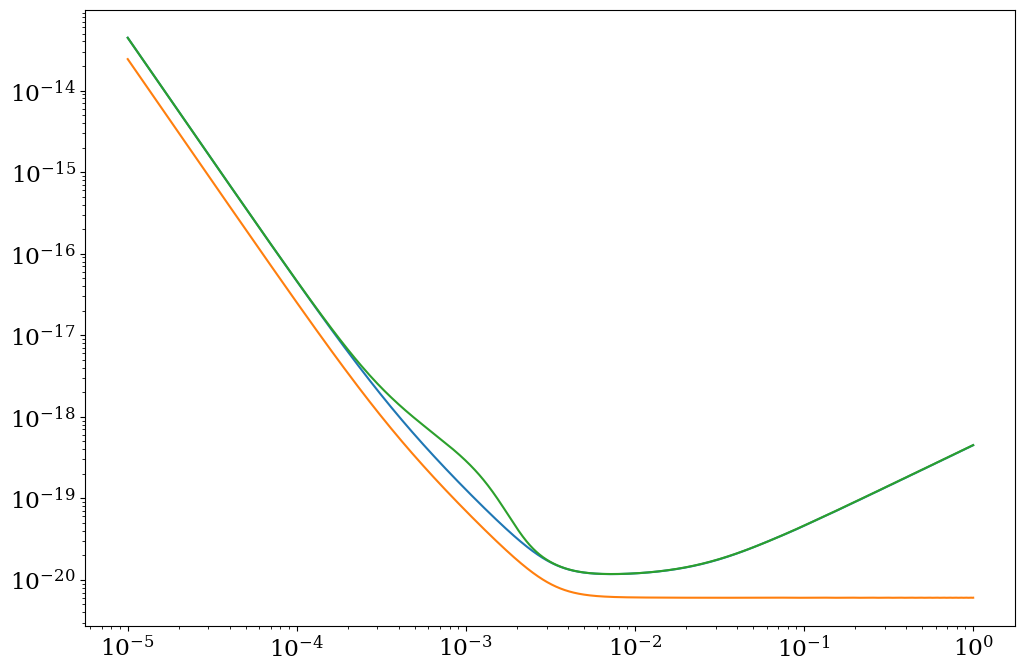

In [47]:
plt.plot(f,Pn**0.5)
plt.plot(f,(Pn*R)**0.5)
plt.plot(f, (a_Snf) ** 0.5)
plt.gca().set_xscale('log')
plt.gca().set_yscale("log")

(1e-21, 1e-14)

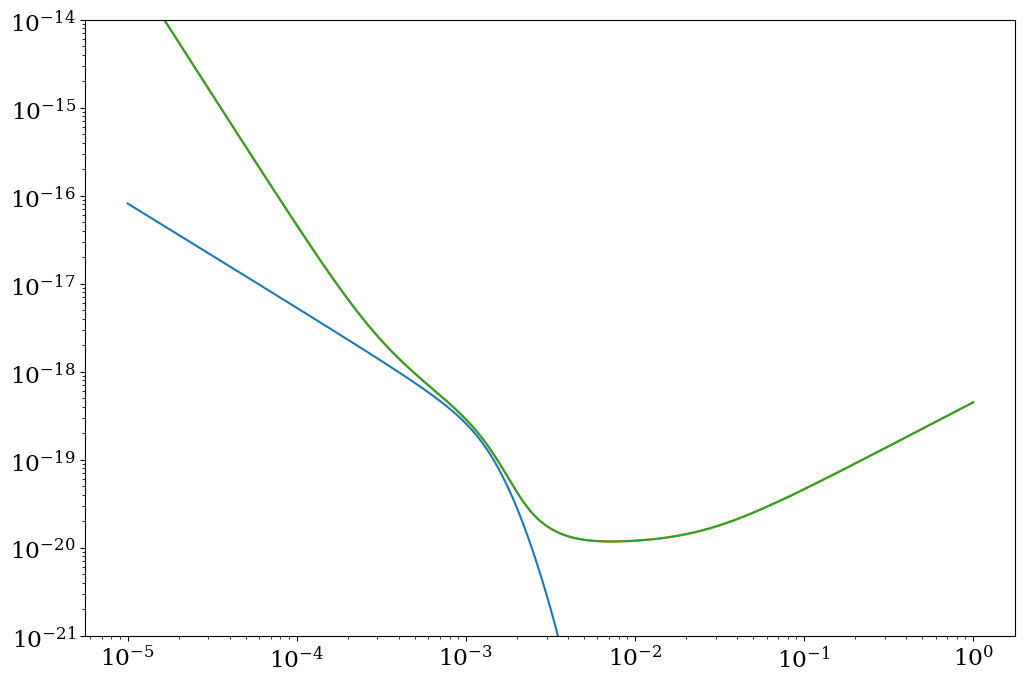

In [48]:
plt.plot(f,confusion_noise**0.5)
plt.plot(f, psd**0.5)
plt.plot(f, a_Snf**0.5)
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.ylim(1e-21,1e-14)

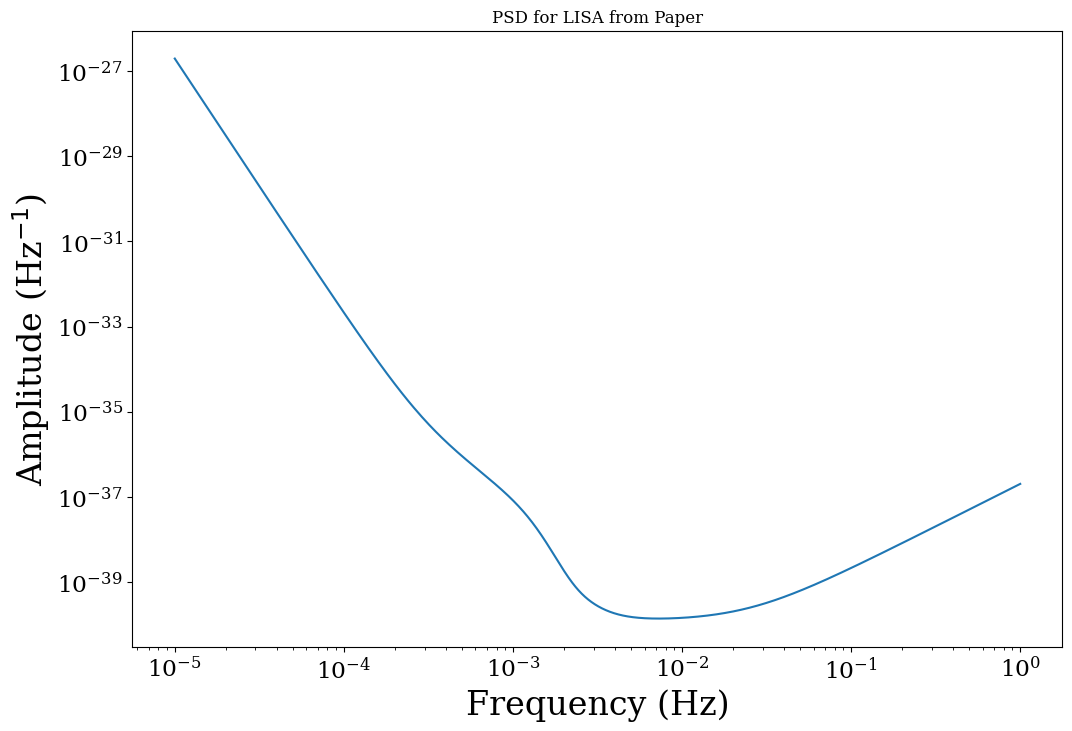

In [49]:
plt.plot(f, a_Snf)
plt.title("PSD for LISA from Paper")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (Hz$^{-1}$)")
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.savefig("psdlisa.png")

In [50]:
ns= np.abs(np.fft.fft(np.random.normal(0.,1.,len(f)))*1e-16)**2

In [51]:
np.trapz(ns**2/(Pn*R),f)

5.4439850890241467e-14

In [52]:
fpsd = FrequencySeries(psd, 1 / 16.0)

In [53]:
fpsd.delta_t

8.000080000800008e-05

In [54]:
noise_fs= pycbc.noise.frequency_noise_from_psd(fpsd)

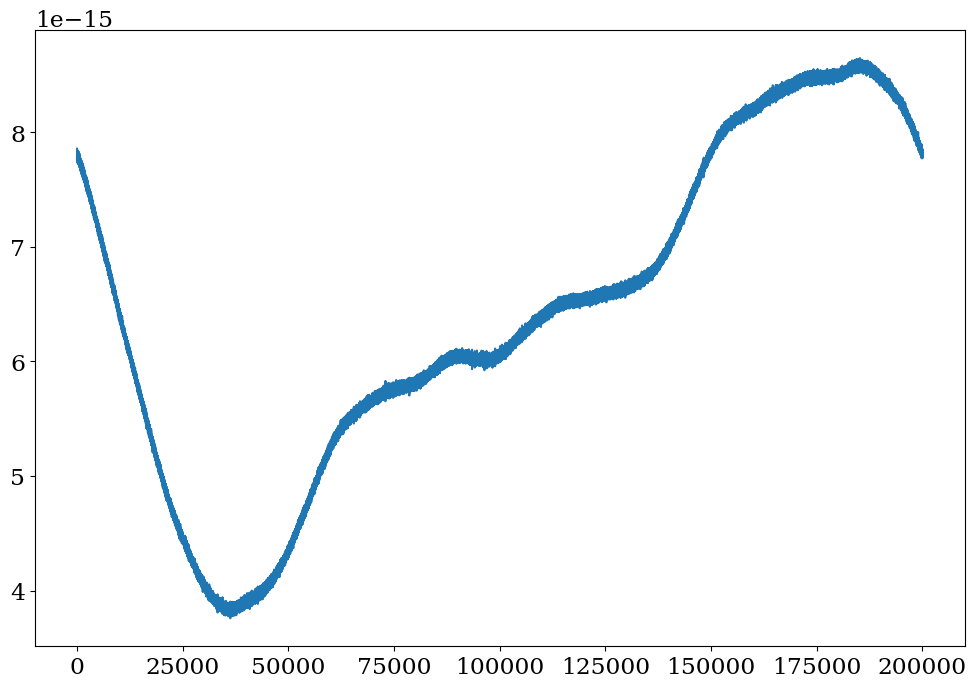

In [55]:
plt.plot(noise_fs.to_timeseries())

In [56]:
# noise_ts = pycbc.noise.gaussian.noise_from_psd(
#     int(16.0 * sample_rate), delta_t=fpsd.delta_t, psd=fpsd, seed=100
# )
noise_ts= noise_fs.to_timeseries()

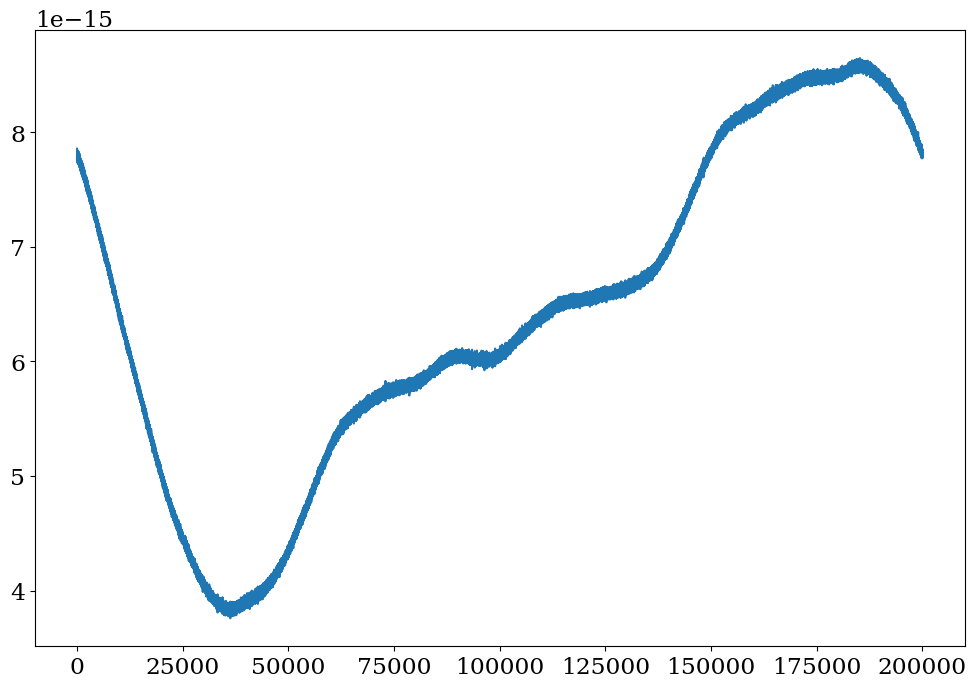

In [57]:
plt.plot(noise_ts)

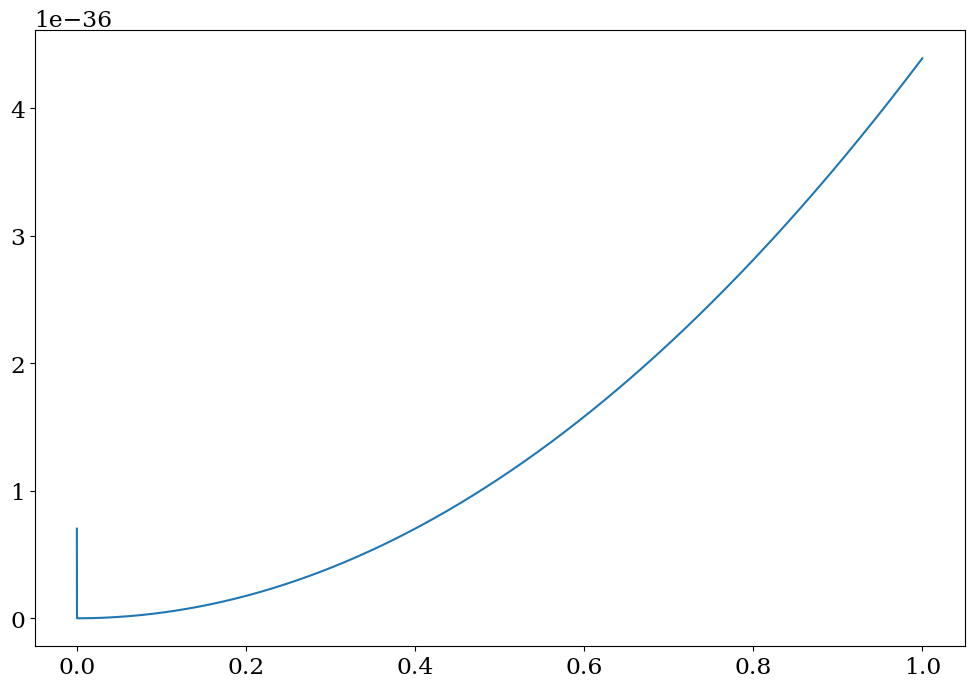

In [65]:
plt.plot(f,pycbc.psd.analytical_space.psd_lisa_oms_noise(f,1e-10))

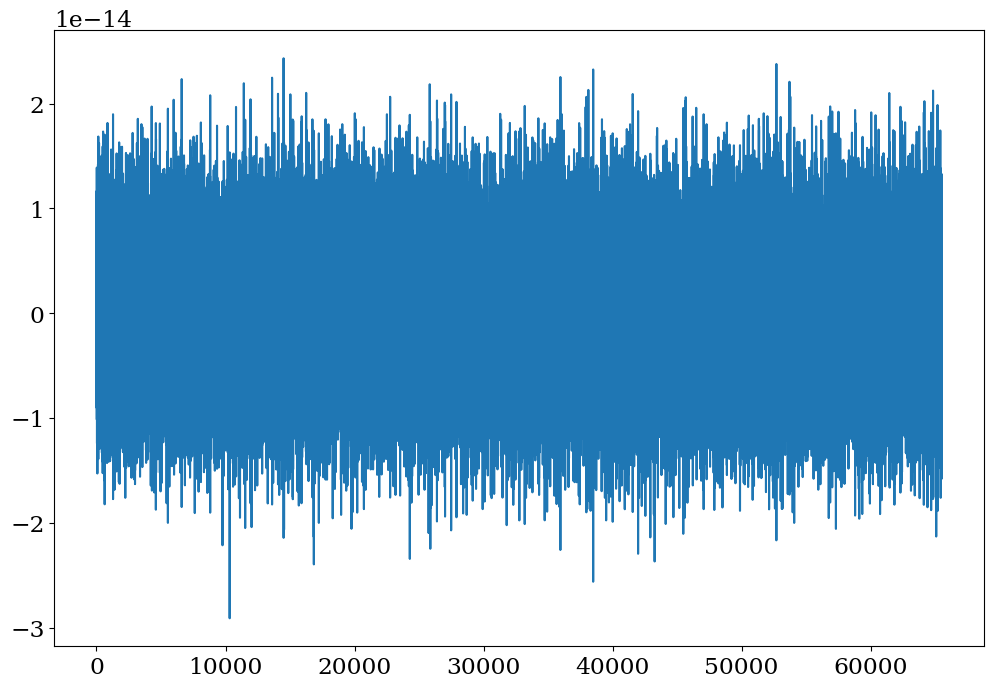

In [86]:
plt.plot(noise_ts)

In [58]:
ht = Fp * hp10[:10000] + Fc * hc10[:10000]

In [59]:
# template = hp10[:10000]/1e5
template = TimeSeries(
    (ht)*1e-6,
    delta_t=1.0 / sample_rate,
)

In [60]:
# Insert the template into the noise
start_time = 4  # Insert the template at 4 seconds
insert_start_index = int(start_time * sample_rate)
noise_ts.data[insert_start_index : insert_start_index + len(template)] += template.data

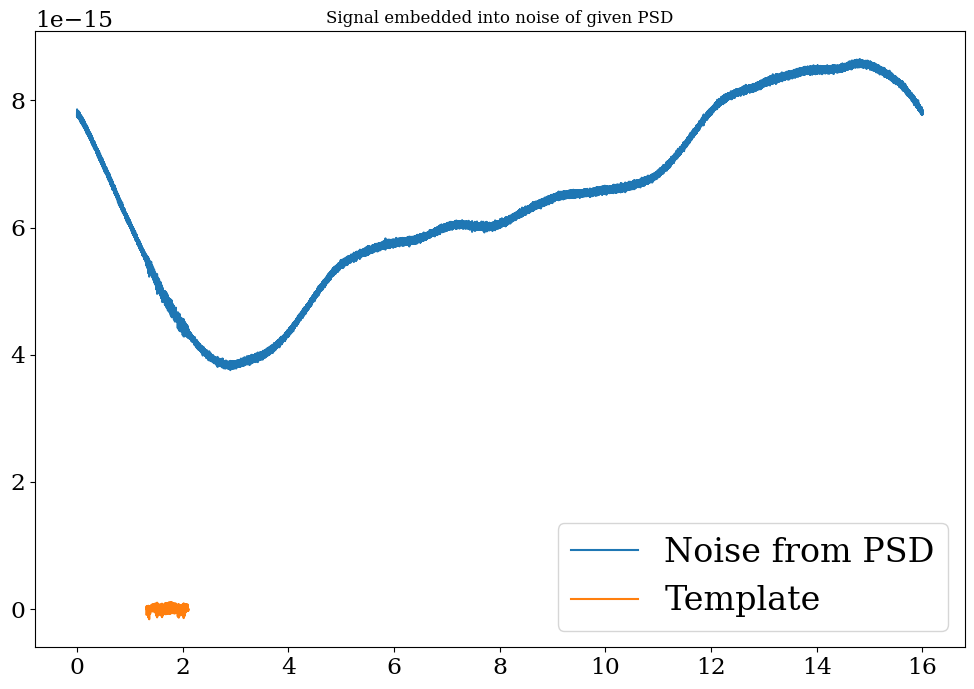

In [61]:
plt.plot(noise_ts.sample_times, noise_ts)
plt.plot(
    noise_ts.sample_times.data[insert_start_index : insert_start_index + len(template)],
    template,
)
plt.title("Signal embedded into noise of given PSD")
plt.legend(["Noise from PSD","Template"])
plt.savefig("signoies.png")
# plt.plot()

In [120]:
data = noise_ts.to_timeseries()
template_new = hp10[:10000] / 1e3
# template_new= np.random.normal(0.,1.,10000)*1e-15
time = np.arange(0.0, 16.0, delta_f)
zero_pad = np.zeros(data.data.size - template_new.size)
template_padded = np.append(template_new, zero_pad)
template_padded = TimeSeries(template_padded, delta_t=1 / sample_rate)

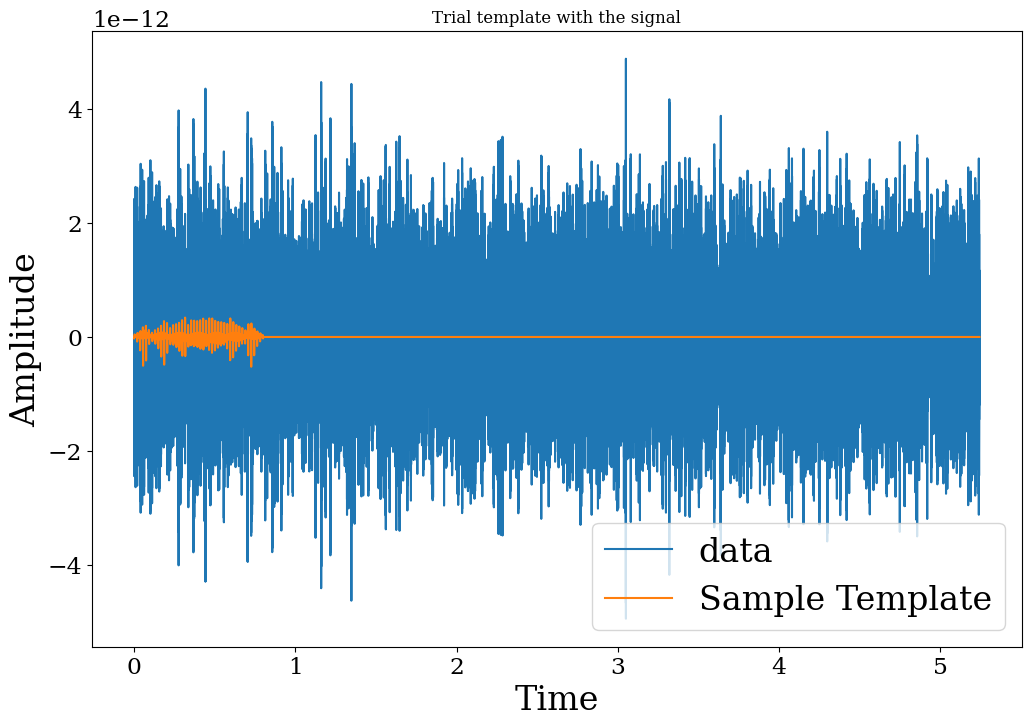

In [121]:
plt.plot(noise_ts.sample_times, data, label="data")
plt.plot(
    noise_ts.sample_times.data,
    template_padded,
    label="Sample Template",
)
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.title("Trial template with the signal")
plt.legend()
# plt.savefig("GWdata_signal.png")

In [122]:
data_fft = np.fft.fft(data)
template_fft = np.fft.fft(template_padded)

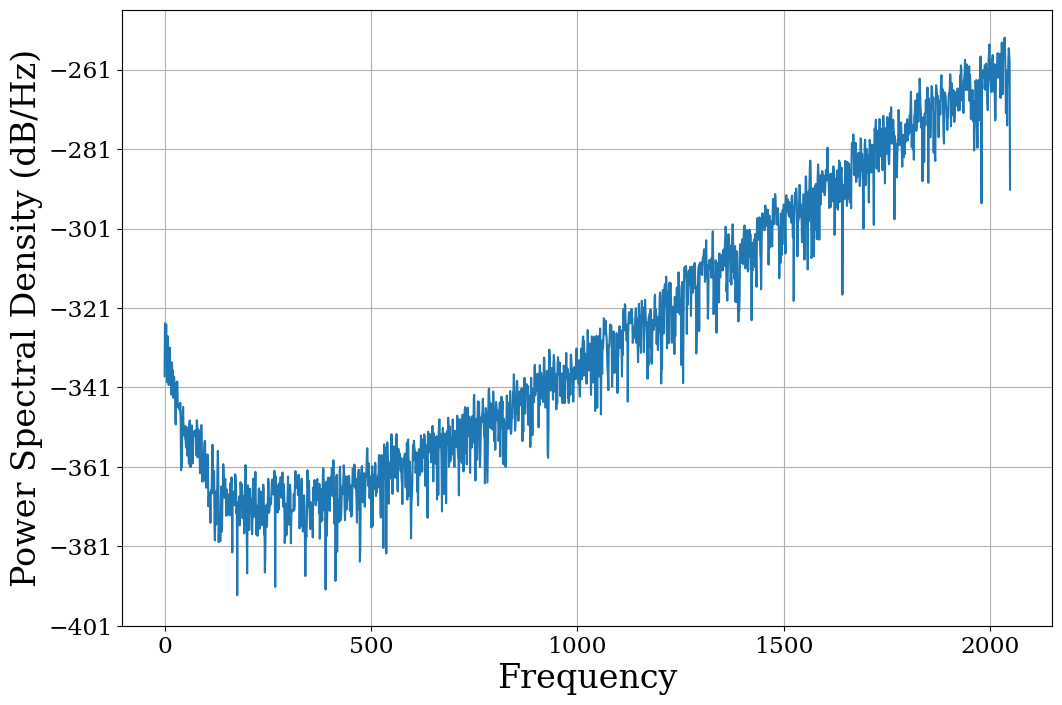

In [126]:
# -- Calculate the PSD of the data
fs = 4096
power_data, freq_psd = plt.psd(data[15*fs:], Fs=fs, NFFT=fs, visible=True)
# plt.title("PSD of pure Gaussian noise")
# plt.savefig("noisepsd.png")
# -- Interpolate to get the PSD values at the needed frequencies
datafreq = np.fft.fftfreq(data.data.size) * fs
power_vec = np.interp(datafreq, freq_psd, power_data)

In [134]:
hf=np.abs(np.fft.fft(hp10[:100000]))**2 + np.abs(np.fft.fft(hc10[:100000]))**2

In [140]:
hf

3781683426039971.5

In [269]:
opt_time= 2* np.fft.ifft(psd*f**2)

In [253]:
lpsd = FrequencySeries(psd, 1 / 16.0)

In [229]:
noise_ts = pycbc.noise.gaussian.noise_from_psd(
    int(16.0 * sample_rate), delta_t=lpsd.delta_t, psd=lpsd, seed=100
)

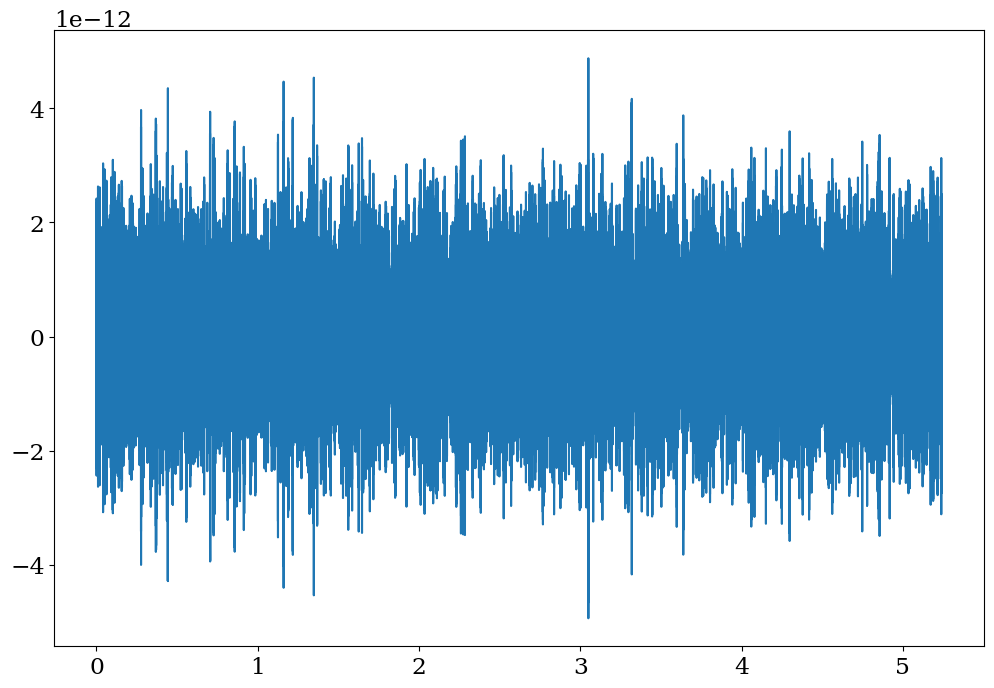

In [230]:
plt.plot(noise_ts.sample_times, noise_ts)

In [245]:
templatehp = TimeSeries(
    (hp10[:10000]) * 1e-3,
    delta_t=1.0 / sample_rate,
)

templatehc = TimeSeries(
    (hc10[:10000]) * 1e-3,
    delta_t=1.0 / sample_rate,
)

In [247]:
# Insert the template into the noise
start_time = 4  # Insert the template at 4 seconds
insert_start_index = int(start_time * sample_rate)
noise_ts.data[insert_start_index : insert_start_index + len(templatehp)] += (
    templatehp.data + templatehc.data
)

Text(0.5, 1.0, 'Signal embedded into noise of given PSD')

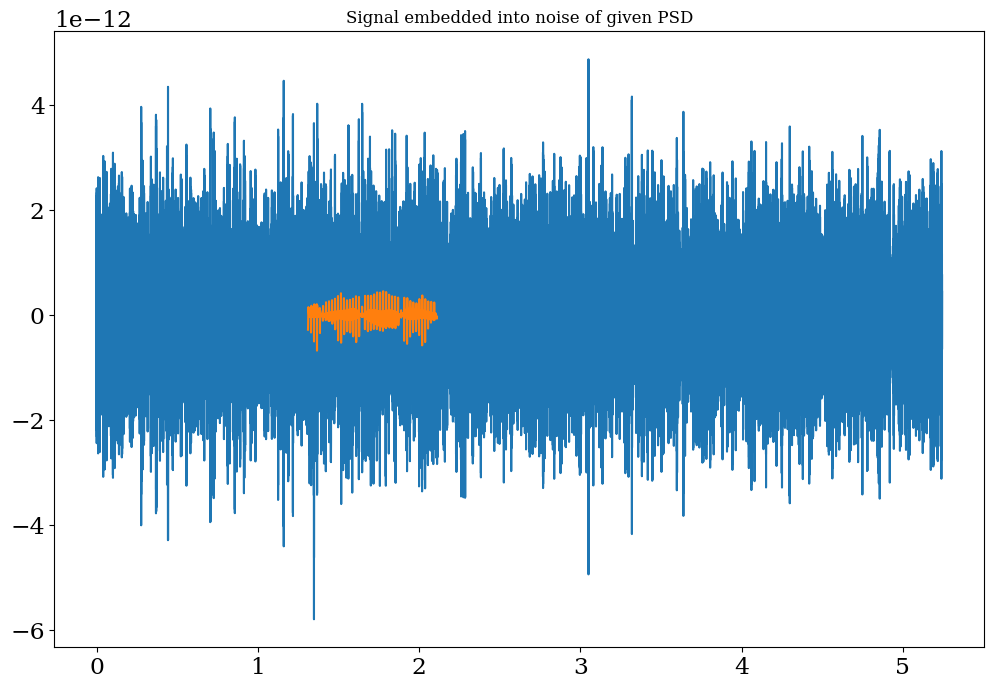

In [248]:
plt.plot(noise_ts.sample_times, noise_ts)
plt.plot(
    noise_ts.sample_times.data[insert_start_index : insert_start_index + len(template)],
    template,
)
plt.title("Signal embedded into noise of given PSD")
# plt.savefig("signoies.png")
# plt.plot()

In [249]:
data = noise_ts.to_timeseries()
# template_new = hp10[:10000] *1e2
template_new = np.random.normal(0.0, 1.0, 10000) * 1e-13
time = np.arange(0.0, 16.0, delta_f)
zero_pad = np.zeros(data.data.size - template_new.size)
template_padded = np.append(template_new, zero_pad)
template_padded = TimeSeries(template_padded, delta_t=1 / sample_rate)

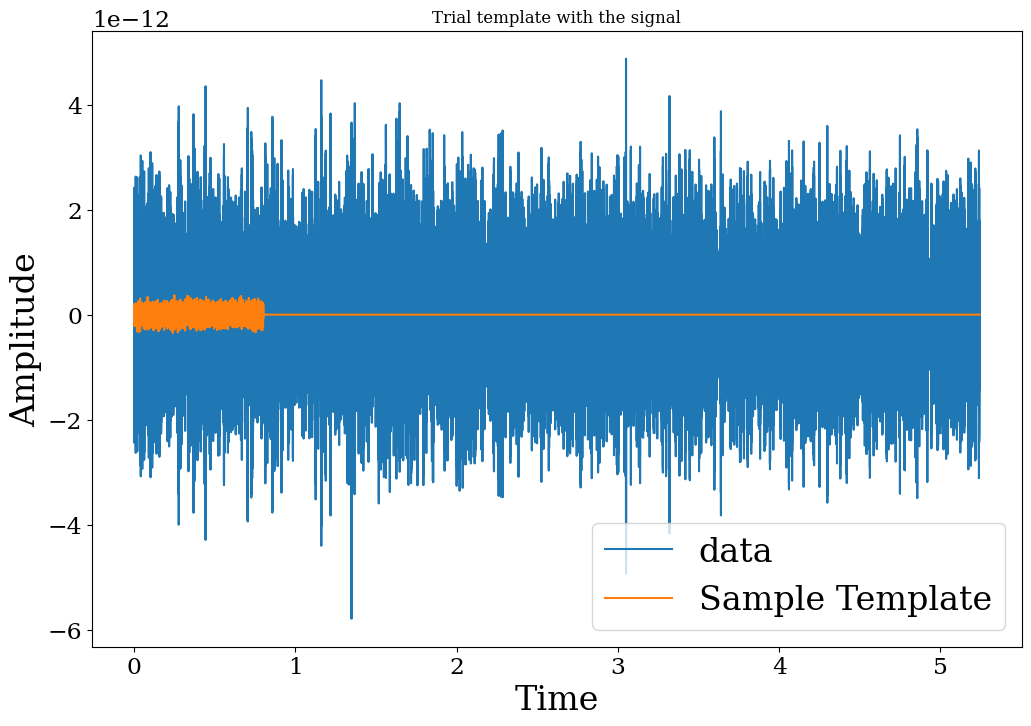

In [250]:
plt.plot(noise_ts.sample_times, data, label="data")
plt.plot(
    noise_ts.sample_times.data,
    template_padded,
    label="Sample Template",
)
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.title("Trial template with the signal")
plt.legend()
# plt.savefig("GWdata_signal.png")

In [238]:
data_fft = np.fft.fft(data)
template_fft = np.fft.fft(template_padded)

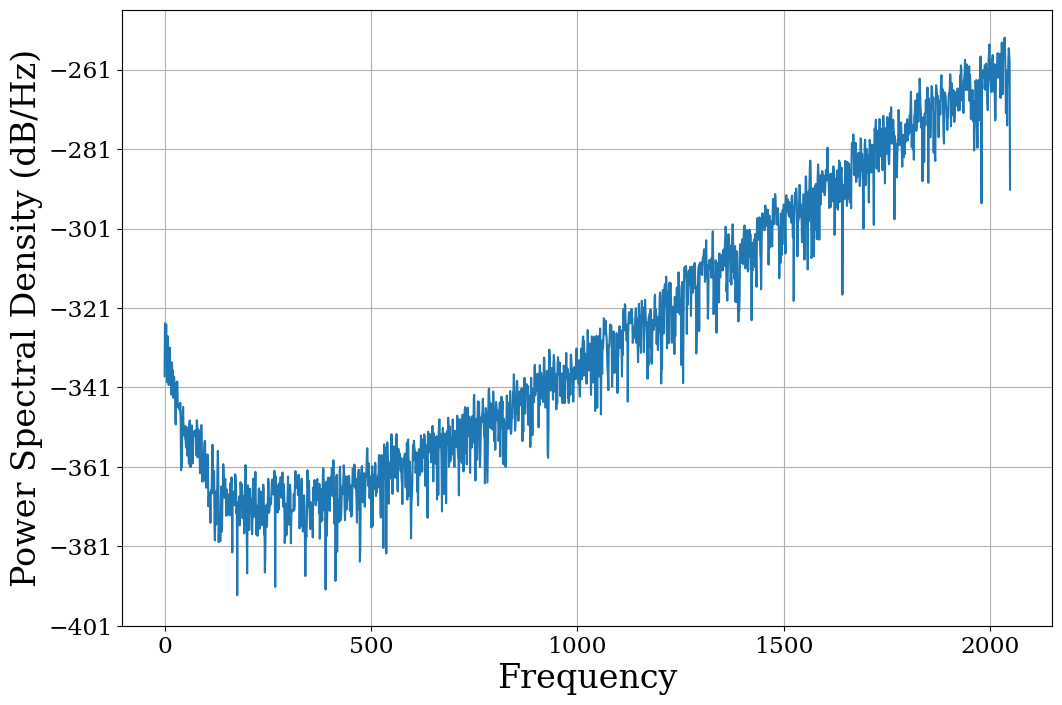

In [239]:
# -- Calculate the PSD of the data
fs = 4096
power_data, freq_psd = plt.psd(data[15 * fs :], Fs=fs, NFFT=fs, visible=True)
# plt.title("PSD of pure Gaussian noise")
# plt.savefig("noisepsd.png")
# -- Interpolate to get the PSD values at the needed frequencies
datafreq = np.fft.fftfreq(data.data.size) * fs
power_vec = np.interp(datafreq, freq_psd, power_data)

In [ ]:
# -- Calculate the matched filter output
optimal = data_fft * template_fft.conjugate() / power_vec
optimal_time = 2 * np.fft.ifft(optimal)